In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator, interp1d
import pickle
import corner

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [4]:
t_Myr_sec = 3.1689E-14 # Conversion from seconds to Myr

# Functions for PIE temperature, cooling/recombination time

Load cooling times and temperatures saved for PIE (main grid run)

In [5]:
# Unique grids in density/metallicity
log_hdens_arr = np.arange(-5, 1.25, 0.25)
log_metals_arr = np.arange(-3, 1.25, 0.25)
N_pts = len(log_hdens_arr)*len(log_metals_arr)

log_hdens_sub_arr = np.arange(-4.25, 1.25, 0.25)
log_metals_sub_arr = np.arange(-0.25, 1.25, 0.25)

In [6]:
# Grid of cooling times, in seconds, need to convert to Myr
# Index only accesses for unique density/metallicities
t_cool_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_grid = t_cool_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

# Store these into a dictionary
logt_cool_dict = {}

# Measurements after adding blackbody heating

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        logt_cool_dict[(log_hdens,log_metals)] = np.log10(t_cool_grid[i,j])

t_cool_sub_grid = np.loadtxt(rootdir+'cloudy_grids/t_cool_sub.txt', delimiter=',')[2::3]*t_Myr_sec
t_cool_sub_grid = t_cool_sub_grid.reshape(len(log_hdens_sub_arr),len(log_metals_sub_arr))

logt_cool_sub_dict = {}

for i in range(len(log_hdens_sub_arr)):
    for j in range(len(log_metals_sub_arr)):
        log_hdens = log_hdens_sub_arr[i]
        log_metals = log_metals_sub_arr[j]
        logt_cool_sub_dict[(log_hdens,log_metals)] = np.log10(t_cool_sub_grid[i,j])

In [7]:
# Load in final temperatures and reshape
logT_grid = np.loadtxt(rootdir+'cloudy_grids/final_flat_logT.dat')[:N_pts]
logT_grid = logT_grid.reshape(len(log_hdens_arr),len(log_metals_arr))

In [8]:
logt_cool_grid = np.zeros(t_cool_grid.shape)

for i in range(len(log_hdens_arr)):
    for j in range(len(log_metals_arr)):
        log_hdens = log_hdens_arr[i]
        log_metals = log_metals_arr[j]
        if logT_grid[i,j] == 4.: # Needed to add blackbody heating
            logt_cool_grid[i,j] = logt_cool_sub_dict[(log_hdens,log_metals)]
        else:
            logt_cool_grid[i,j] = logt_cool_dict[(log_hdens,log_metals)]

Interpolate temperatures and cooling times

In [9]:
logT_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logT_grid)
logt_cool_interp = RegularGridInterpolator((log_hdens_arr, log_metals_arr), logt_cool_grid)

Interpolate recombination times

In [10]:
# From CLOUDY calculations
logT_rec_grid = np.array([4. , 4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4,
        6.6, 6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

logq_rec_grid = np.log10(np.array([5.14e-12, 3.75e-12, 2.72e-12, 1.96e-12, 1.40e-12, 9.95e-13,
        6.99e-13, 4.86e-13, 3.34e-13, 2.26e-13, 1.50e-13, 9.80e-14,
        6.27e-14, 3.93e-14, 2.41e-14, 1.44e-14, 8.47e-15, 4.86e-15,
        2.74e-15, 1.52e-15, 1.52e-15]))

In [11]:
logq_rec_interp = interp1d(logT_rec_grid, logq_rec_grid, fill_value='extrapolate')

In [12]:
def logt_rec(log_hdens, logT, logq_rec_interp):
    
    logq = logq_rec_interp(logT)
    logt_rec = np.log10((10**log_hdens*10**logq)**-1*t_Myr_sec)
    
    return logt_rec

Functions to get distributions of $T$, $t_\mathrm{rec}$ and $t_\mathrm{cool}/t_\mathrm{rec}$

In [13]:
def get_cooling_dist(log_hdens_samples, log_metals_samples, logq_rec_interp, logt_cool_interp):
    
    # Distribution of PIE temperatures
    logT_samples = logT_interp((log_hdens_samples, log_metals_samples))
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = logt_cool_interp((log_hdens_samples, log_metals_samples))
    
    return np.array(logT_samples), np.array(logt_rec_samples), np.array(logt_cool_samples)

In [14]:
loaddir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/'

Diagnostic plots

In [15]:
log_hdens_test_arr = np.arange(-4.6, -2.3, 0.05)

Text(0, 0.5, '$\\log(T_\\mathrm{PIE}/\\mathrm{K})$')

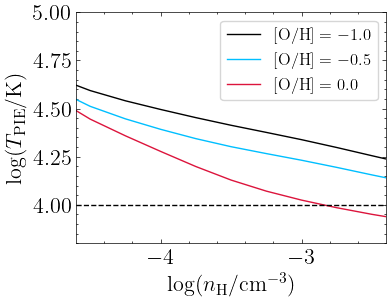

In [16]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-1.0)), label=r'$[\mathrm{O/H}]=-1.0$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,-0.5)), label=r'$[\mathrm{O/H}]=-0.5$')
ax.plot(log_hdens_test_arr, logT_interp((log_hdens_test_arr,0.0)), label=r'$[\mathrm{O/H}]=0.0$')

ax.axhline(4.0,linestyle='--')
ax.set_xlim(-4.6,-2.4)
ax.set_ylim(3.8,5.0)

ax.legend()

ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(T_\mathrm{PIE}/\mathrm{K})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

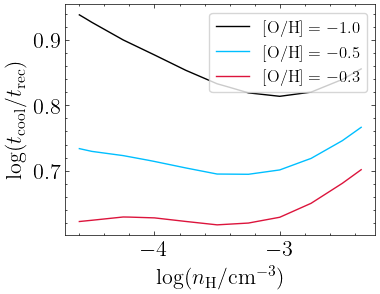

In [17]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.5$')

ax.plot(log_hdens_test_arr,
        logt_cool_interp((log_hdens_test_arr,-0.3))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-0.3)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-0.3$')

ax.legend()
ax.set_xlabel(r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

In [18]:
log_metals_test_arr = np.arange(-3.0, 1., 0.25)

Text(0, 0.5, '$\\log(T/\\mathrm{K})$')

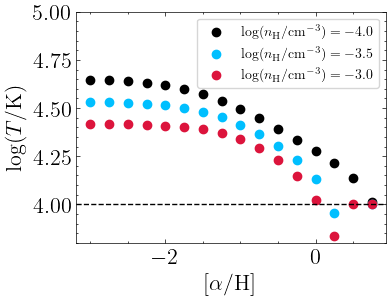

In [19]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logT_interp((-4.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logT_interp((-3.5,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logT_interp((-3.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

ax.axhline(4.0,linestyle='--')
#ax.set_xlim(-4.6,-2.4)
ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log(T/\mathrm{K})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/\\mathrm{Myr})$')

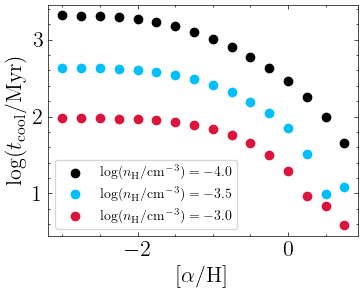

In [20]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logt_cool_interp((-4.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logt_cool_interp((-3.5,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logt_cool_interp((-3.,log_metals_test_arr)), label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

#ax.set_xlim(-4.6,-2.4)
#ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/\mathrm{Myr})$')

Text(0, 0.5, '$\\log (n_\\mathrm{H} \\Lambda / k_B)$')

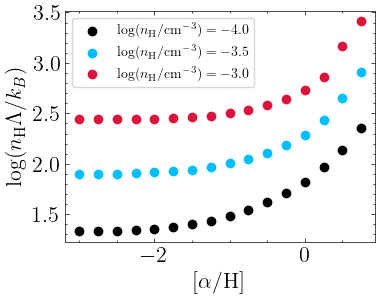

In [21]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logT_interp((-4.,log_metals_test_arr))-logt_cool_interp((-4.,log_metals_test_arr)), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logT_interp((-3.5,log_metals_test_arr))-logt_cool_interp((-3.5,log_metals_test_arr)), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logT_interp((-3.,log_metals_test_arr))-logt_cool_interp((-3.,log_metals_test_arr)), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

#ax.set_xlim(-4.6,-2.4)
#ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log (n_\mathrm{H} \Lambda / k_B)$')

Text(0, 0.5, '$\\log(t_\\mathrm{rec}/\\mathrm{Myr})$')

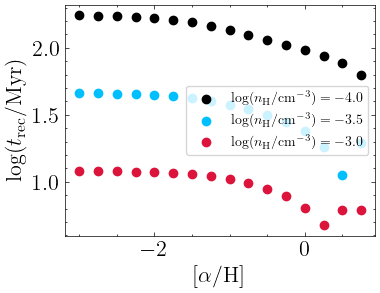

In [22]:
fig, ax = plt.subplots(1,figsize=(4,3))
ax.scatter(log_metals_test_arr, logt_rec(-4.,logT_interp((-4.,log_metals_test_arr)),logq_rec_interp), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.0$')
ax.scatter(log_metals_test_arr, logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')
ax.scatter(log_metals_test_arr, logt_rec(-3.,logT_interp((-3.,log_metals_test_arr)),logq_rec_interp), 
           label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.0$')

#ax.set_xlim(-4.6,-2.4)
#ax.set_ylim(3.8,5.0)

ax.legend(fontsize=10)

ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/\\mathrm{Myr})$')

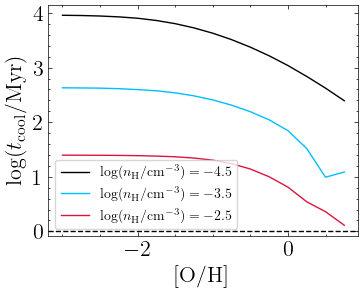

In [23]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_metals_test_arr,
        logt_cool_interp((-4.5,log_metals_test_arr)), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-3.5,log_metals_test_arr)), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-2.5,log_metals_test_arr)), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$')

ax.axhline(0, linestyle='--')

ax.legend(fontsize=10)
ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/\mathrm{Myr})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

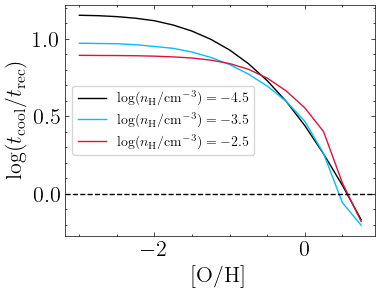

In [24]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(log_metals_test_arr,
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$')

ax.plot(log_metals_test_arr,
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$')

ax.axhline(0, linestyle='--')

ax.legend(fontsize=10)
ax.set_xlabel(r'$\mathrm{[O/H]}$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

Text(0, 0.5, '$\\log(t_\\mathrm{cool}/t_\\mathrm{rec})$')

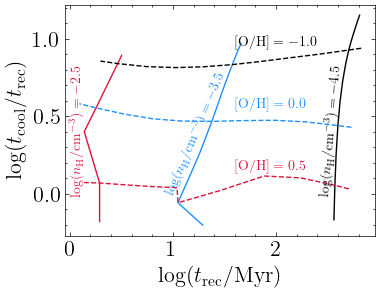

In [25]:
fig, ax = plt.subplots(1,figsize=(4,3))

ax.plot(logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-4.5,log_metals_test_arr))-logt_rec(-4.5,logT_interp((-4.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',color='black')

ax.text(2.4,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-4.5$',fontsize=10, rotation=85, color='black')

ax.plot(logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-3.5,log_metals_test_arr))-logt_rec(-3.5,logT_interp((-3.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',color='dodgerblue')

ax.text(0.9,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-3.5$',fontsize=10, rotation=67, color='dodgerblue')

ax.plot(logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp),
        logt_cool_interp((-2.5,log_metals_test_arr))-logt_rec(-2.5,logT_interp((-2.5,log_metals_test_arr)),logq_rec_interp), 
        label=r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',color='crimson')

ax.text(0.0,0.0,r'$\log(n_\mathrm{H}/\mathrm{cm}^{-3})=-2.5$',fontsize=10, rotation=90, color='crimson')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,-1.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,-1.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=-1.0$',color='black', linestyle='--')

ax.text(1.6,0.95,r'$\mathrm{[O/H]}=-1.0$',fontsize=10)

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.0))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.0)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.0$',color='dodgerblue', linestyle='--')

ax.text(1.6,0.55,r'$\mathrm{[O/H]}=0.0$',fontsize=10,color='dodgerblue')

ax.plot(logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp),
        logt_cool_interp((log_hdens_test_arr,0.5))-logt_rec(log_hdens_test_arr,logT_interp((log_hdens_test_arr,0.5)),logq_rec_interp), 
        label=r'$[\mathrm{O/H}]=0.5$',color='crimson', linestyle='--')

ax.text(1.6,0.15,r'$\mathrm{[O/H]}=0.5$',fontsize=10,color='crimson')

ax.set_xlabel(r'$\log(t_\mathrm{rec}/\mathrm{Myr})$')
ax.set_ylabel(r'$\log(t_\mathrm{cool}/t_\mathrm{rec})$')

# z=0.67, PIE

## c1

In [26]:
z_067_c1_PIE_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/two_phase.csv')

### c1H

In [27]:
z_067_c1H_PIE_logT, z_067_c1H_PIE_logt_rec, z_067_c1H_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_067_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([2.10000e+01, 3.80000e+01, 2.24000e+02, 8.45000e+02, 3.79400e+03,
        2.12500e+04, 1.05167e+05, 4.65620e+04, 2.08700e+03, 1.20000e+01]),
 array([4.12557365, 4.15518611, 4.18479857, 4.21441103, 4.24402348,
        4.27363594, 4.3032484 , 4.33286086, 4.36247332, 4.39208578,
        4.42169824]),
 <BarContainer object of 10 artists>)

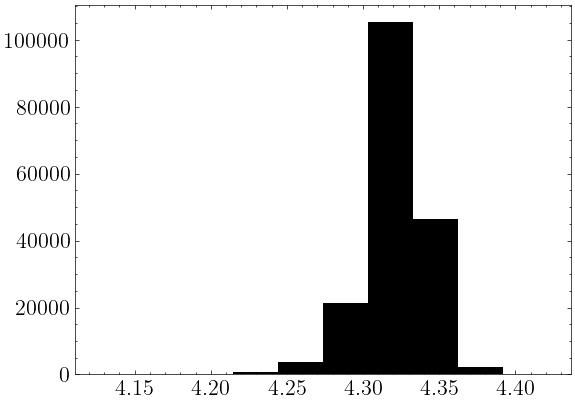

In [28]:
plt.hist(z_067_c1H_PIE_logT)

In [29]:
get_quantiles(z_067_c1H_PIE_logT)

4.32 -0.02 0.02


(array([2.6000e+01, 1.4400e+02, 7.2300e+02, 1.5910e+03, 4.5910e+03,
        1.2785e+04, 5.7558e+04, 8.5710e+04, 1.6510e+04, 3.6200e+02]),
 array([0.25233603, 0.37125722, 0.49017841, 0.6090996 , 0.72802079,
        0.84694198, 0.96586318, 1.08478437, 1.20370556, 1.32262675,
        1.44154794]),
 <BarContainer object of 10 artists>)

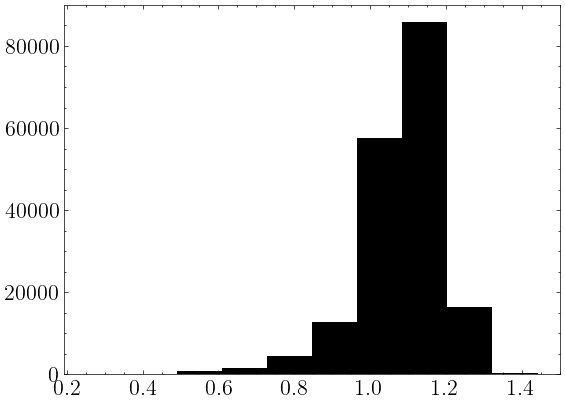

In [30]:
plt.hist(z_067_c1H_PIE_logt_rec)

In [31]:
get_quantiles(z_067_c1H_PIE_logt_rec)

1.1 -0.1 0.08


(array([9.00000e+00, 2.80000e+01, 5.98000e+02, 3.08730e+04, 1.02924e+05,
        3.89700e+04, 5.61300e+03, 8.38000e+02, 1.43000e+02, 4.00000e+00]),
 array([0.72122402, 0.73513147, 0.74903892, 0.76294638, 0.77685383,
        0.79076128, 0.80466873, 0.81857618, 0.83248363, 0.84639108,
        0.86029853]),
 <BarContainer object of 10 artists>)

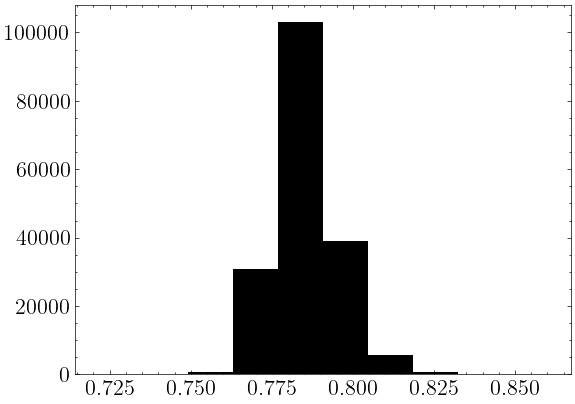

In [32]:
plt.hist(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

In [33]:
get_quantiles(z_067_c1H_PIE_logt_cool-z_067_c1H_PIE_logt_rec)

0.78 -0.01 0.01


### c1L

In [34]:
z_067_c1L_PIE_logT, z_067_c1L_PIE_logt_rec, z_067_c1L_PIE_logt_cool = get_cooling_dist(z_067_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_067_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   71.,   415.,   619.,  1055.,  4694., 18231., 41277., 56928.,
        44976., 11734.]),
 array([3.88158186, 3.94620447, 4.01082709, 4.0754497 , 4.14007232,
        4.20469493, 4.26931755, 4.33394016, 4.39856277, 4.46318539,
        4.527808  ]),
 <BarContainer object of 10 artists>)

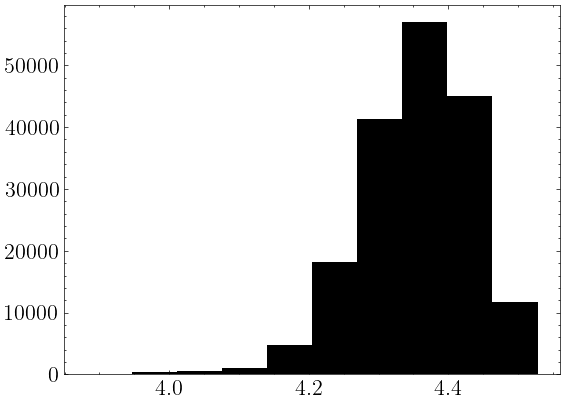

In [35]:
plt.hist(z_067_c1L_PIE_logT)

In [36]:
get_quantiles(z_067_c1L_PIE_logT)

4.36 -0.08 0.07


(array([  151.,   897.,  2670., 12415., 39824., 57653., 44703., 17705.,
         3740.,   242.]),
 array([1.54047038, 1.61152877, 1.68258716, 1.75364556, 1.82470395,
        1.89576234, 1.96682074, 2.03787913, 2.10893752, 2.17999592,
        2.25105431]),
 <BarContainer object of 10 artists>)

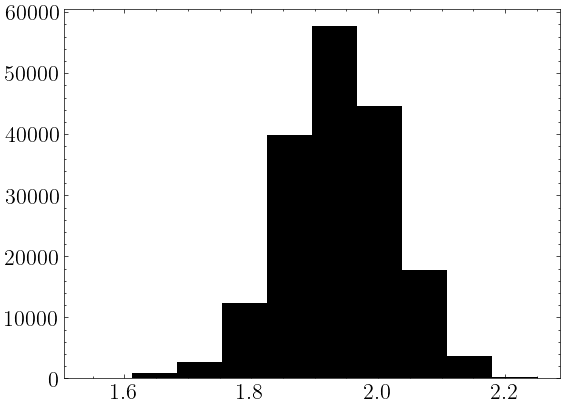

In [37]:
plt.hist(z_067_c1L_PIE_logt_rec)

In [38]:
get_quantiles(z_067_c1L_PIE_logt_rec)

1.94 -0.08 0.09


(array([6.7000e+01, 5.1000e+01, 1.5900e+02, 5.4200e+02, 1.4020e+03,
        5.7120e+03, 1.8229e+04, 4.5512e+04, 7.2400e+04, 3.5926e+04]),
 array([-0.38369615, -0.25370482, -0.12371348,  0.00627785,  0.13626918,
         0.26626052,  0.39625185,  0.52624319,  0.65623452,  0.78622585,
         0.91621719]),
 <BarContainer object of 10 artists>)

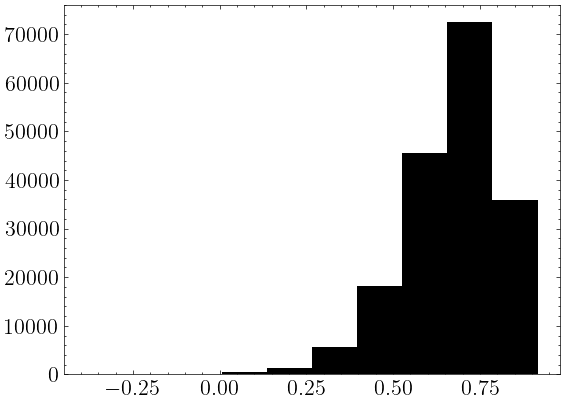

In [39]:
plt.hist(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec)

In [40]:
get_quantiles(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec)

0.69 -0.16 0.11


In [41]:
z_067_c1L_metals = z_067_c1_PIE_samples['log_metals_p2']
z_067_c1L_cool = z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec

(array([ 5736., 23234., 41100., 46145., 34874., 19522.,  7225.,  1728.,
          318.,   118.]),
 array([-1.18040707, -0.96898392, -0.75756076, -0.54613761, -0.33471445,
        -0.1232913 ,  0.08813186,  0.29955501,  0.51097816,  0.72240132,
         0.93382447]),
 <BarContainer object of 10 artists>)

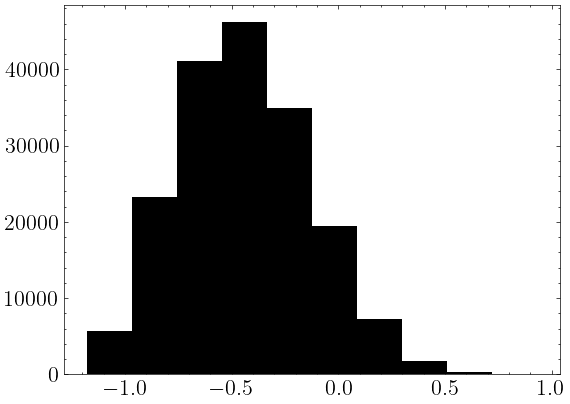

In [42]:
plt.hist(z_067_c1L_metals)

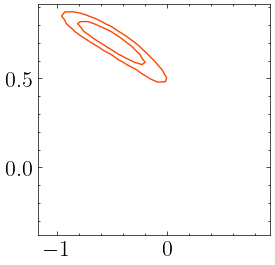

In [43]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

# z=1.04, PIE

## c1

In [44]:
z_104_c1_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c1.csv')

In [45]:
z_104_c1_PIE_logT, z_104_c1_PIE_logt_rec, z_104_c1_PIE_logt_cool = get_cooling_dist(z_104_c1_PIE_samples['log_hdens'],
                                                                                    z_104_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([  362.,   899.,  2181.,  9018., 31285., 28951.,  5749.,  1022.,
          475.,    58.]),
 array([3.81398646, 3.87794793, 3.94190939, 4.00587085, 4.06983232,
        4.13379378, 4.19775524, 4.26171671, 4.32567817, 4.38963963,
        4.4536011 ]),
 <BarContainer object of 10 artists>)

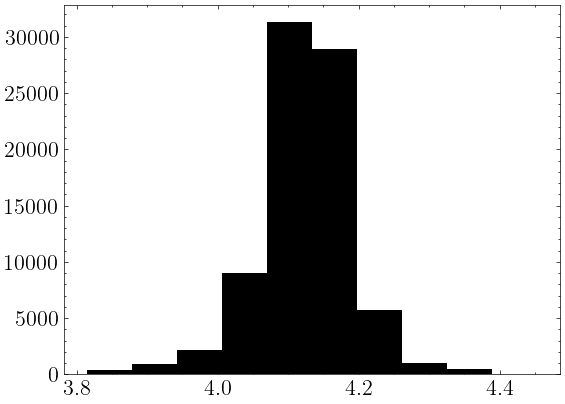

In [46]:
plt.hist(z_104_c1_PIE_logT)

In [47]:
get_quantiles(z_104_c1_PIE_logT)

4.13 -0.06 0.05


(array([9.8000e+01, 1.4030e+03, 1.6821e+04, 5.3373e+04, 7.0090e+03,
        7.2800e+02, 3.1600e+02, 1.9100e+02, 5.3000e+01, 8.0000e+00]),
 array([0.35906317, 0.56805963, 0.77705609, 0.98605256, 1.19504902,
        1.40404548, 1.61304194, 1.8220384 , 2.03103487, 2.24003133,
        2.44902779]),
 <BarContainer object of 10 artists>)

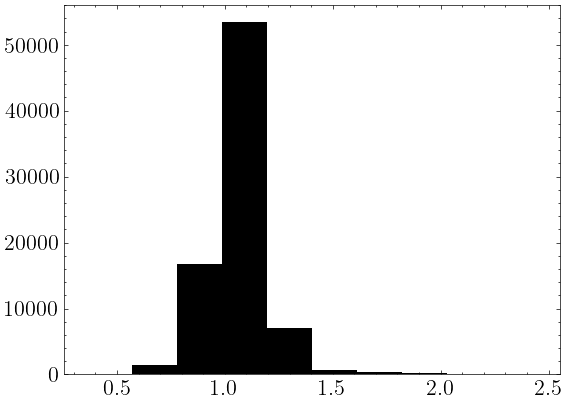

In [48]:
plt.hist(z_104_c1_PIE_logt_rec)

In [49]:
get_quantiles(z_104_c1_PIE_logt_rec)

1.06 -0.1 0.11


(array([7.0000e+00, 4.2000e+01, 4.7300e+02, 1.6860e+03, 6.4020e+03,
        3.0482e+04, 3.2888e+04, 6.8610e+03, 1.0480e+03, 1.1100e+02]),
 array([0.17120889, 0.23405672, 0.29690456, 0.35975239, 0.42260022,
        0.48544806, 0.54829589, 0.61114372, 0.67399156, 0.73683939,
        0.79968722]),
 <BarContainer object of 10 artists>)

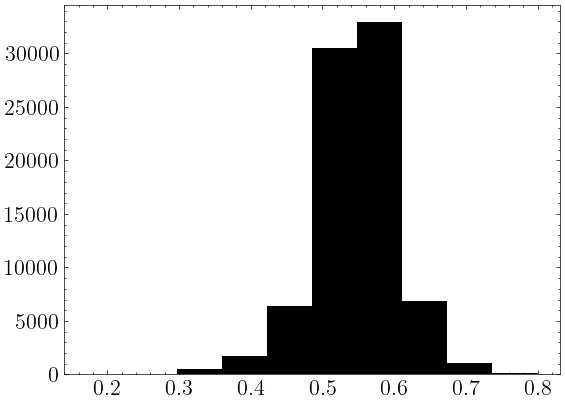

In [50]:
plt.hist(z_104_c1_PIE_logt_cool-z_104_c1_PIE_logt_rec)

In [51]:
get_quantiles(z_104_c1_PIE_logt_cool-z_104_c1_PIE_logt_rec)

0.55 -0.05 0.05


## c2

In [52]:
z_104_c2_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/one_phase_c2.csv')

In [53]:
z_104_c2_PIE_logT, z_104_c2_PIE_logt_rec, z_104_c2_PIE_logt_cool = get_cooling_dist(z_104_c2_PIE_samples['log_hdens'],
                                                                                    z_104_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   18.,    25.,   672., 13804., 13786., 17334., 17142., 14186.,
         2923.,   110.]),
 array([3.72511584, 3.77922312, 3.83333039, 3.88743767, 3.94154495,
        3.99565223, 4.0497595 , 4.10386678, 4.15797406, 4.21208134,
        4.26618862]),
 <BarContainer object of 10 artists>)

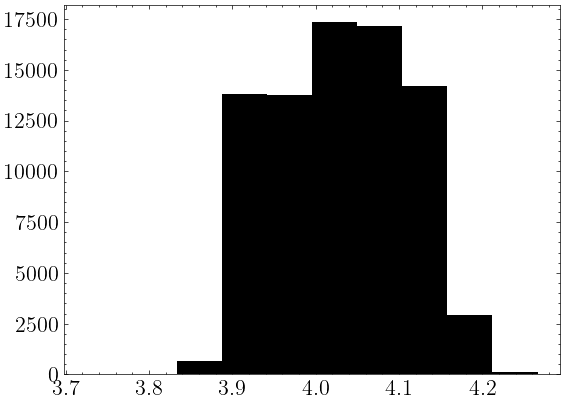

In [54]:
plt.hist(z_104_c2_PIE_logT)

In [55]:
get_quantiles(z_104_c2_PIE_logT)

4.03 -0.1 0.08


(array([1.4500e+02, 2.0700e+03, 8.7840e+03, 1.6547e+04, 2.2571e+04,
        1.8489e+04, 8.9280e+03, 2.2060e+03, 2.3900e+02, 2.1000e+01]),
 array([0.8408098 , 0.92068394, 1.00055809, 1.08043224, 1.16030639,
        1.24018053, 1.32005468, 1.39992883, 1.47980298, 1.55967713,
        1.63955127]),
 <BarContainer object of 10 artists>)

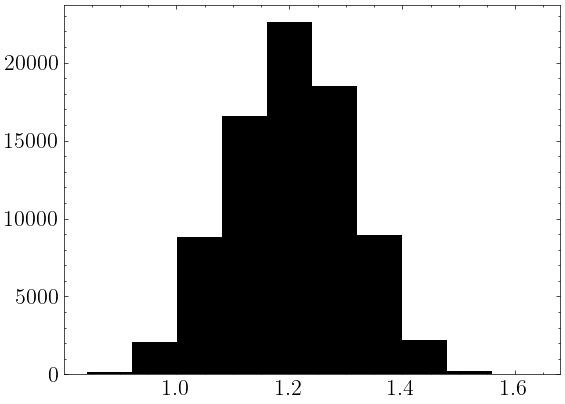

In [56]:
plt.hist(z_104_c2_PIE_logt_rec)

In [57]:
get_quantiles(z_104_c2_PIE_logt_rec)

1.21 -0.11 0.11


(array([   35.,   233.,  2011.,  5039., 11126., 16682., 18616., 18422.,
         7302.,   534.]),
 array([0.01369833, 0.07322171, 0.13274508, 0.19226846, 0.25179184,
        0.31131522, 0.3708386 , 0.43036197, 0.48988535, 0.54940873,
        0.60893211]),
 <BarContainer object of 10 artists>)

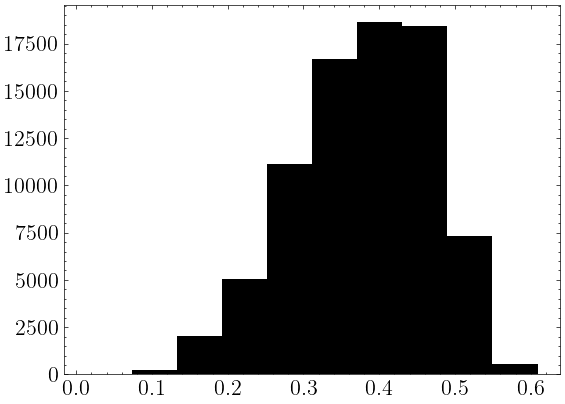

In [58]:
plt.hist(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

In [59]:
get_quantiles(z_104_c2_PIE_logt_cool-z_104_c2_PIE_logt_rec)

0.39 -0.1 0.09


## c3

In [60]:
z_104_c3_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/two_phase_c3.csv')

### c3H

In [61]:
z_104_c3H_PIE_logT, z_104_c3H_PIE_logt_rec, z_104_c3H_PIE_logt_cool = get_cooling_dist(z_104_c3_PIE_samples['log_hdens_p1'],
                                                                                             z_104_c3_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([4.0000e+00, 6.0000e+00, 1.9500e+02, 1.5060e+03, 8.5170e+03,
        4.0526e+04, 6.6578e+04, 3.7234e+04, 2.1870e+04, 3.5640e+03]),
 array([3.84029226, 3.90578066, 3.97126907, 4.03675747, 4.10224588,
        4.16773428, 4.23322268, 4.29871109, 4.36419949, 4.42968789,
        4.4951763 ]),
 <BarContainer object of 10 artists>)

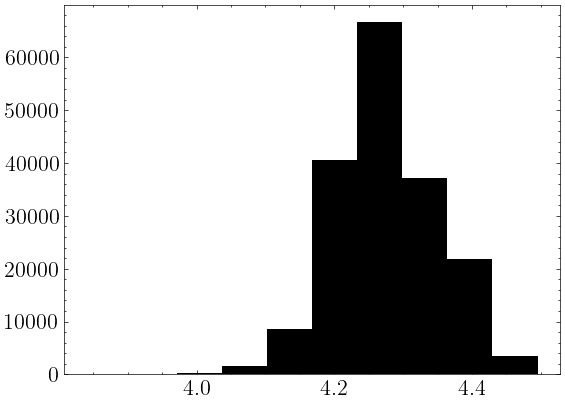

In [62]:
plt.hist(z_104_c3H_PIE_logT)

In [63]:
get_quantiles(z_104_c3H_PIE_logT)

4.27 -0.06 0.09


(array([  216.,  1711.,  6453., 19375., 33481., 42157., 41534., 26345.,
         8164.,   564.]),
 array([0.24690295, 0.40016308, 0.5534232 , 0.70668333, 0.85994346,
        1.01320359, 1.16646372, 1.31972385, 1.47298397, 1.6262441 ,
        1.77950423]),
 <BarContainer object of 10 artists>)

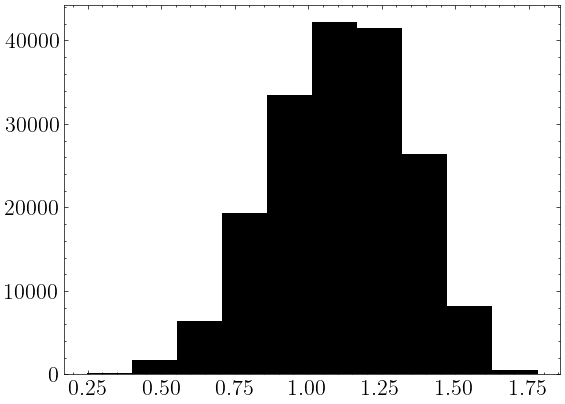

In [64]:
plt.hist(z_104_c3H_PIE_logt_rec)

In [65]:
get_quantiles(z_104_c3H_PIE_logt_rec)

1.12 -0.25 0.23


In [66]:
np.median(z_104_c3H_PIE_logt_rec)-np.percentile(z_104_c3H_PIE_logt_rec,100*(1-cdf_1sig))

0.25495535278238257

In [67]:
np.percentile(z_104_c3H_PIE_logt_rec, 100*cdf_1sig)-np.median(z_104_c3H_PIE_logt_rec)

0.23160382969757332

(array([4.0000e+00, 1.5000e+01, 5.5000e+02, 6.4860e+03, 4.0460e+04,
        4.2205e+04, 3.1447e+04, 2.6233e+04, 2.3205e+04, 9.3950e+03]),
 array([0.37295214, 0.4297694 , 0.48658667, 0.54340393, 0.60022119,
        0.65703845, 0.71385571, 0.77067297, 0.82749023, 0.8843075 ,
        0.94112476]),
 <BarContainer object of 10 artists>)

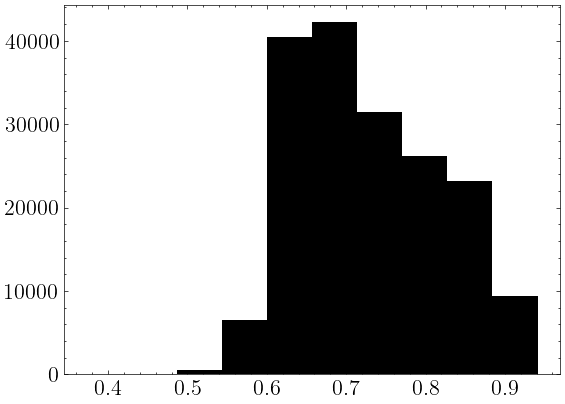

In [68]:
plt.hist(z_104_c3H_PIE_logt_cool-z_104_c3H_PIE_logt_rec)

In [69]:
get_quantiles(z_104_c3H_PIE_logt_cool-z_104_c3H_PIE_logt_rec)

0.71 -0.08 0.12


### c3L

In [70]:
z_104_c3L_PIE_logT, z_104_c3L_PIE_logt_rec, z_104_c3L_PIE_logt_cool = get_cooling_dist(z_104_c3_PIE_samples['log_hdens_p2'],
                                                                                             z_104_c3_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([ 1192.,  8090., 22531., 22824., 34647., 38903., 24592., 14066.,
         8129.,  5026.]),
 array([3.67605084, 3.7848232 , 3.89359556, 4.00236793, 4.11114029,
        4.21991265, 4.32868501, 4.43745738, 4.54622974, 4.6550021 ,
        4.76377446]),
 <BarContainer object of 10 artists>)

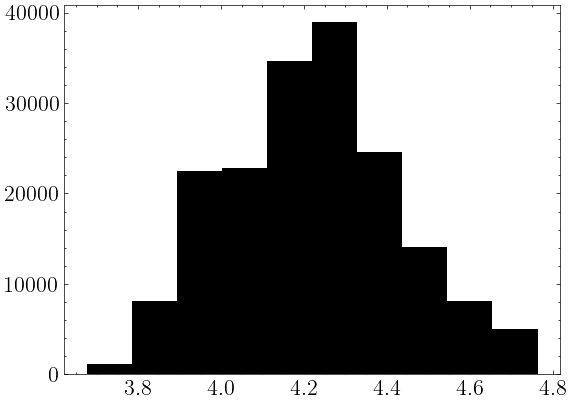

In [71]:
plt.hist(z_104_c3L_PIE_logT)

In [72]:
get_quantiles(z_104_c3L_PIE_logT)

4.22 -0.23 0.21


(array([ 3773., 31338., 55437., 40593., 25225., 10381.,  5401.,  3514.,
         2429.,  1909.]),
 array([1.05702129, 1.28364151, 1.51026173, 1.73688195, 1.96350217,
        2.19012239, 2.41674261, 2.64336283, 2.86998304, 3.09660326,
        3.32322348]),
 <BarContainer object of 10 artists>)

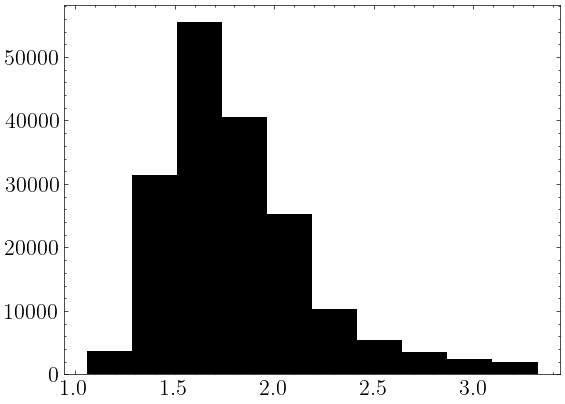

In [73]:
plt.hist(z_104_c3L_PIE_logt_rec)

In [74]:
get_quantiles(z_104_c3L_PIE_logt_rec)

1.73 -0.25 0.4


In [75]:
np.median(z_104_c3L_PIE_logt_rec)-np.percentile(z_104_c3L_PIE_logt_rec,100*(1-cdf_1sig))

0.25320220095451496

(array([  946.,  5809., 15024., 16884., 23439., 35130., 40055., 23792.,
        13294.,  5627.]),
 array([-0.4793697 , -0.31501019, -0.15065068,  0.01370883,  0.17806834,
         0.34242785,  0.50678736,  0.67114686,  0.83550637,  0.99986588,
         1.16422539]),
 <BarContainer object of 10 artists>)

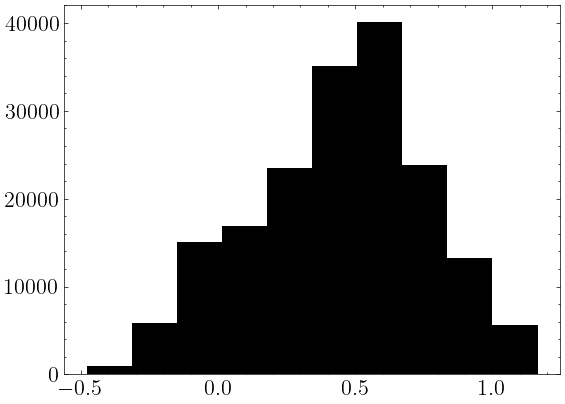

In [76]:
plt.hist(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec)

In [77]:
get_quantiles(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec)

0.48 -0.4 0.28


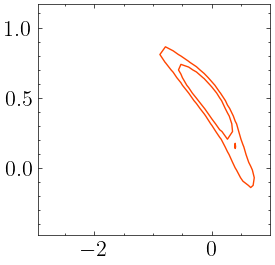

In [78]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

## c4

In [79]:
z_104_c4_PIE_samples = pd.read_csv(loaddir+'z=1.04430667/cloudy_fits/two_phase_c4.csv')

### c4H

In [80]:
z_104_c4H_PIE_logT, z_104_c4H_PIE_logt_rec, z_104_c4H_PIE_logt_cool = get_cooling_dist(z_104_c4_PIE_samples['log_hdens_p1'],
                                                                                             z_104_c4_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([3.1000e+01, 1.4700e+02, 3.4500e+02, 1.3010e+03, 4.4850e+03,
        1.7189e+04, 4.9541e+04, 6.8420e+04, 3.4116e+04, 4.4250e+03]),
 array([3.76976011, 3.84023128, 3.91070246, 3.98117363, 4.0516448 ,
        4.12211597, 4.19258714, 4.26305831, 4.33352949, 4.40400066,
        4.47447183]),
 <BarContainer object of 10 artists>)

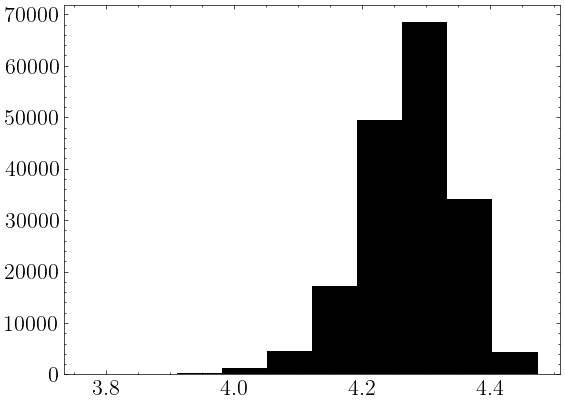

In [81]:
plt.hist(z_104_c4H_PIE_logT)

In [82]:
get_quantiles(z_104_c4H_PIE_logT)

4.28 -0.08 0.07


(array([5.1000e+01, 3.0300e+02, 1.1710e+03, 5.0970e+03, 1.8652e+04,
        4.9564e+04, 6.3638e+04, 3.5853e+04, 5.3800e+03, 2.9100e+02]),
 array([-0.14922768,  0.02265673,  0.19454115,  0.36642556,  0.53830997,
         0.71019438,  0.88207879,  1.0539632 ,  1.22584761,  1.39773202,
         1.56961643]),
 <BarContainer object of 10 artists>)

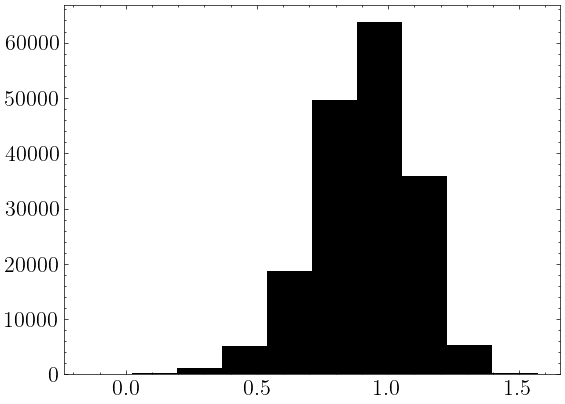

In [83]:
plt.hist(z_104_c4H_PIE_logt_rec)

In [84]:
get_quantiles(z_104_c4H_PIE_logt_rec)

0.92 -0.19 0.17


(array([5.1000e+01, 1.5100e+02, 4.9400e+02, 1.7680e+03, 8.7450e+03,
        3.3472e+04, 6.1743e+04, 4.3674e+04, 2.0394e+04, 9.5080e+03]),
 array([0.42636218, 0.47607058, 0.52577898, 0.57548737, 0.62519577,
        0.67490416, 0.72461256, 0.77432096, 0.82402935, 0.87373775,
        0.92344615]),
 <BarContainer object of 10 artists>)

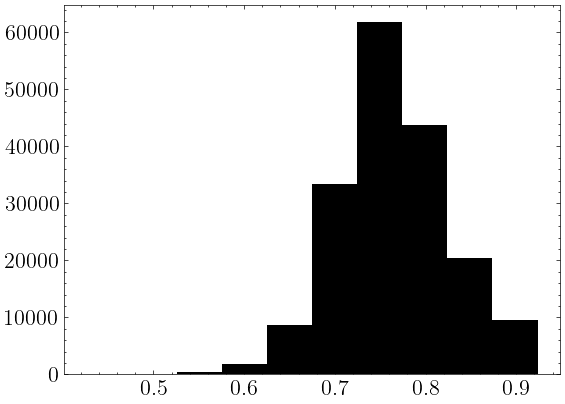

In [85]:
plt.hist(z_104_c4H_PIE_logt_cool-z_104_c4H_PIE_logt_rec)

In [86]:
get_quantiles(z_104_c4H_PIE_logt_cool-z_104_c4H_PIE_logt_rec)

0.76 -0.05 0.06


### c4L

In [87]:
z_104_c4L_PIE_logT, z_104_c4L_PIE_logt_rec, z_104_c4L_PIE_logt_cool = get_cooling_dist(z_104_c4_PIE_samples['log_hdens_p2'],
                                                                                             z_104_c4_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  176.,  1488.,  3955.,  7614., 23895., 49170., 51481., 31947.,
         9777.,   497.]),
 array([3.66568397, 3.76701571, 3.86834744, 3.96967917, 4.07101091,
        4.17234264, 4.27367438, 4.37500611, 4.47633784, 4.57766958,
        4.67900131]),
 <BarContainer object of 10 artists>)

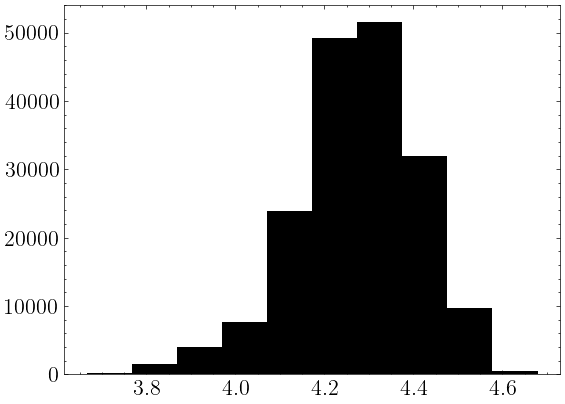

In [88]:
plt.hist(z_104_c4L_PIE_logT)

In [89]:
get_quantiles(z_104_c4L_PIE_logT)

4.28 -0.13 0.13


(array([  138.,  1657., 15255., 49868., 54830., 36332., 15920.,  5309.,
          613.,    78.]),
 array([0.68333681, 0.88548192, 1.08762703, 1.28977213, 1.49191724,
        1.69406235, 1.89620746, 2.09835256, 2.30049767, 2.50264278,
        2.70478789]),
 <BarContainer object of 10 artists>)

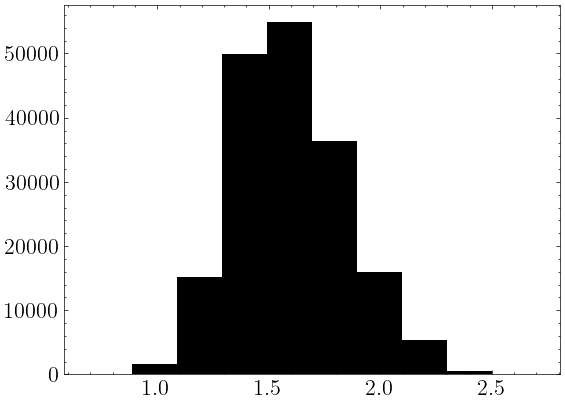

In [90]:
plt.hist(z_104_c4L_PIE_logt_rec)

In [91]:
get_quantiles(z_104_c4L_PIE_logt_rec)

1.57 -0.22 0.28


(array([   82.,   777.,  1936.,  4489., 12152., 30162., 53615., 51911.,
        23227.,  1649.]),
 array([-0.26567467, -0.13054155,  0.00459158,  0.13972471,  0.27485784,
         0.40999096,  0.54512409,  0.68025722,  0.81539035,  0.95052348,
         1.0856566 ]),
 <BarContainer object of 10 artists>)

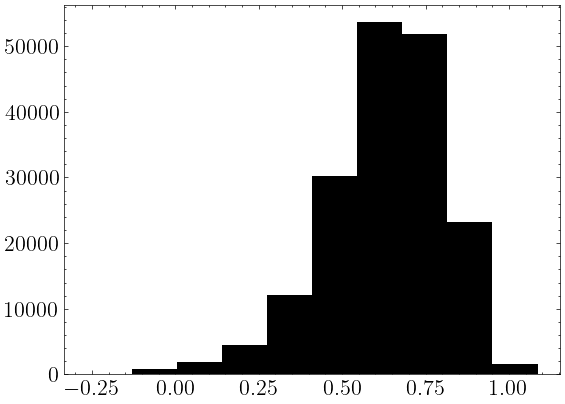

In [92]:
plt.hist(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec)

In [93]:
get_quantiles(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec)

0.65 -0.18 0.15


In [94]:
np.median(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec)

0.6498770217217729

In [95]:
np.percentile(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec,100*cdf_1sig)-np.median(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec)

0.15416114511735313

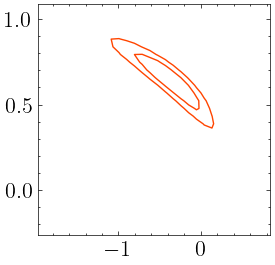

In [96]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_104_c4_PIE_samples['log_metals_p2']), 
              np.array(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

# z=1.09, PIE

## c1

In [97]:
z_109_c1_PIE_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/two_phase.csv')

### c1H

In [98]:
z_109_c1H_PIE_logT, z_109_c1H_PIE_logt_rec, z_109_c1H_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_109_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 4928., 39705., 46493., 39439., 23246., 13919.,  7595.,  3464.,
         1098.,   113.]),
 array([3.82261328, 3.85130641, 3.87999953, 3.90869265, 3.93738578,
        3.9660789 , 3.99477202, 4.02346514, 4.05215827, 4.08085139,
        4.10954451]),
 <BarContainer object of 10 artists>)

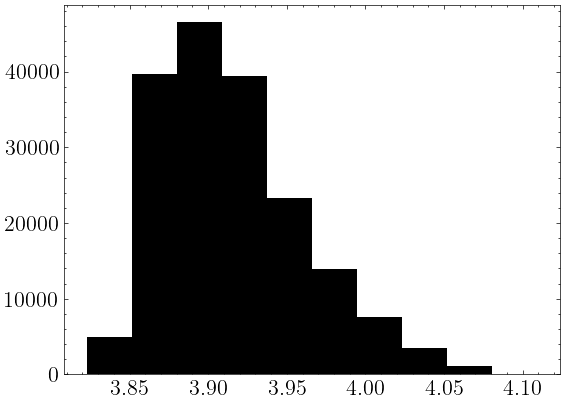

In [99]:
plt.hist(z_109_c1H_PIE_logT)

In [100]:
get_quantiles(z_109_c1H_PIE_logT), np.percentile(z_109_c1H_PIE_logT,100*cdf_3sig)

3.91 -0.04 0.05


(None, 4.07245163168895)

(array([9.3000e+01, 1.2170e+03, 5.1860e+03, 1.9376e+04, 5.1754e+04,
        6.7133e+04, 2.9910e+04, 5.0670e+03, 2.5600e+02, 8.0000e+00]),
 array([0.54253218, 0.60011118, 0.65769019, 0.7152692 , 0.7728482 ,
        0.83042721, 0.88800622, 0.94558522, 1.00316423, 1.06074324,
        1.11832224]),
 <BarContainer object of 10 artists>)

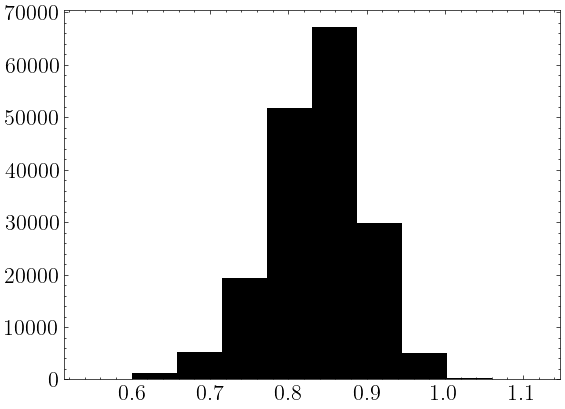

In [101]:
plt.hist(z_109_c1H_PIE_logt_rec)

In [102]:
get_quantiles(z_109_c1H_PIE_logt_rec)

0.84 -0.06 0.06


(array([ 5953., 37500., 58175., 39795., 20372., 11043.,  4825.,  1923.,
          326.,    88.]),
 array([0.23371033, 0.27015033, 0.30659033, 0.34303033, 0.37947033,
        0.41591033, 0.45235033, 0.48879033, 0.52523033, 0.56167033,
        0.59811033]),
 <BarContainer object of 10 artists>)

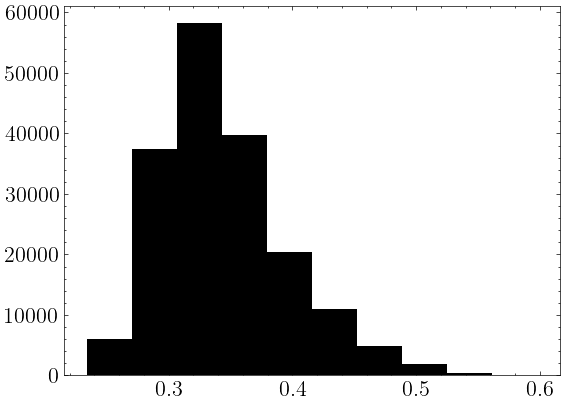

In [103]:
plt.hist(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

In [104]:
get_quantiles(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

0.34 -0.04 0.06


### c1L

In [105]:
z_109_c1L_PIE_logT, z_109_c1L_PIE_logt_rec, z_109_c1L_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_109_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([  305.,  2319., 13058., 33399., 23404., 33488., 36678., 25253.,
        10756.,  1340.]),
 array([3.75272385, 3.8191351 , 3.88554635, 3.9519576 , 4.01836885,
        4.08478011, 4.15119136, 4.21760261, 4.28401386, 4.35042511,
        4.41683636]),
 <BarContainer object of 10 artists>)

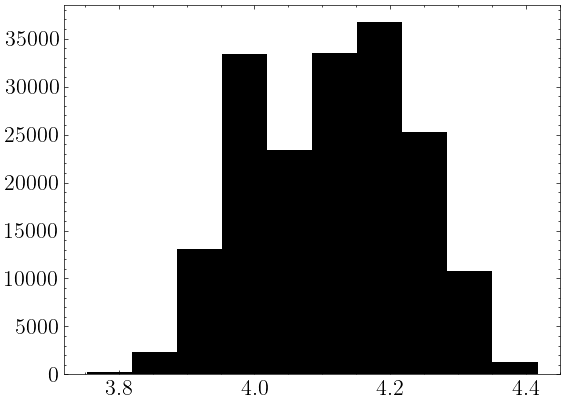

In [106]:
plt.hist(z_109_c1L_PIE_logT)

In [107]:
get_quantiles(z_109_c1L_PIE_logT), np.percentile(z_109_c1L_PIE_logT,100*cdf_3sig)

4.12 -0.14 0.12


(None, 4.369354436156034)

(array([1.2200e+02, 1.7580e+03, 8.7630e+03, 2.6496e+04, 4.9122e+04,
        5.2046e+04, 3.1721e+04, 8.8120e+03, 1.1380e+03, 2.2000e+01]),
 array([1.28331389, 1.34726702, 1.41122014, 1.47517327, 1.53912639,
        1.60307952, 1.66703264, 1.73098577, 1.79493889, 1.85889201,
        1.92284514]),
 <BarContainer object of 10 artists>)

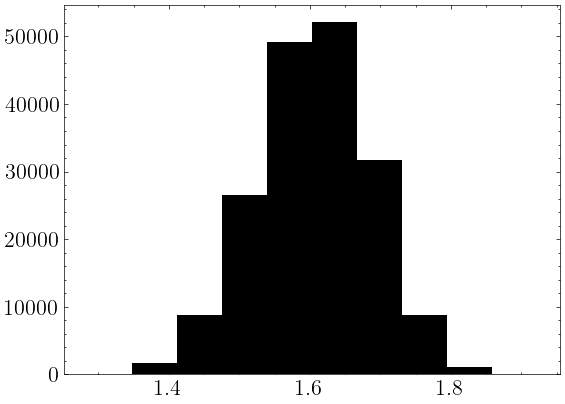

In [108]:
plt.hist(z_109_c1L_PIE_logt_rec)

In [109]:
get_quantiles(z_109_c1L_PIE_logt_rec)

1.61 -0.08 0.08


In [110]:
np.percentile(z_109_c1L_PIE_logt_rec, 100*cdf_1sig)-np.median(z_109_c1L_PIE_logt_rec)

0.08023048708998215

(array([ 3282.,  5467.,  8435., 13219., 14532., 21210., 39721., 41197.,
        26561.,  6376.]),
 array([-0.47799026, -0.35117705, -0.22436384, -0.09755064,  0.02926257,
         0.15607578,  0.28288899,  0.4097022 ,  0.5365154 ,  0.66332861,
         0.79014182]),
 <BarContainer object of 10 artists>)

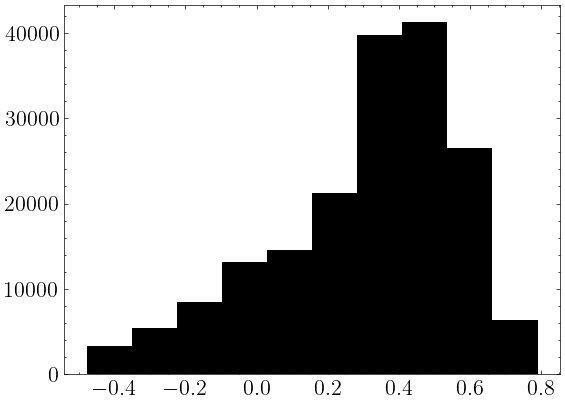

In [111]:
plt.hist(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)

In [112]:
get_quantiles(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)

0.36 -0.35 0.19


In [113]:
np.median(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec)-np.percentile(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec,100*(1-cdf_1sig))

0.3470595298322483

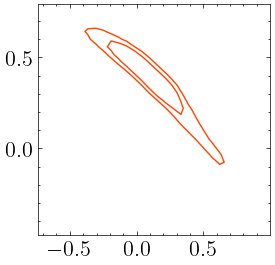

In [114]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

# z=1.16, PIE

## c1

In [115]:
z_116_c1_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c1.csv')

In [116]:
z_116_c1_PIE_logT, z_116_c1_PIE_logt_rec, z_116_c1_PIE_logt_cool = get_cooling_dist(z_116_c1_PIE_samples['log_hdens'],
                                                                                    z_116_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.3000e+01, 5.0400e+02, 2.8880e+03, 1.0455e+04, 2.0485e+04,
        2.3294e+04, 1.5388e+04, 5.7820e+03, 1.0680e+03, 1.1300e+02]),
 array([4.41071325, 4.41688824, 4.42306322, 4.42923821, 4.43541319,
        4.44158818, 4.44776316, 4.45393814, 4.46011313, 4.46628811,
        4.4724631 ]),
 <BarContainer object of 10 artists>)

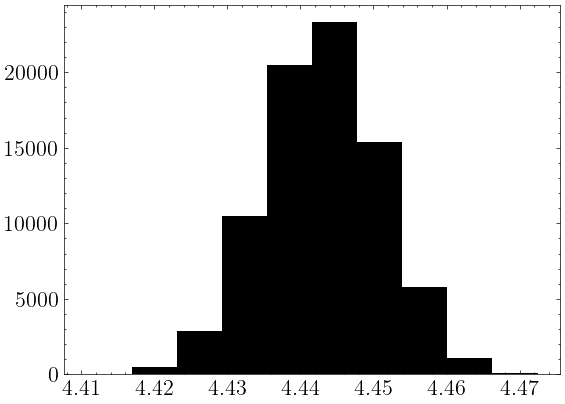

In [117]:
plt.hist(z_116_c1_PIE_logT)

In [118]:
get_quantiles(z_116_c1_PIE_logT)

4.44 -0.01 0.01


(array([   46.,   677.,  3704., 11253., 20431., 22814., 14627.,  5374.,
          967.,   107.]),
 array([1.13665301, 1.16541259, 1.19417218, 1.22293176, 1.25169135,
        1.28045093, 1.30921052, 1.3379701 , 1.36672969, 1.39548927,
        1.42424886]),
 <BarContainer object of 10 artists>)

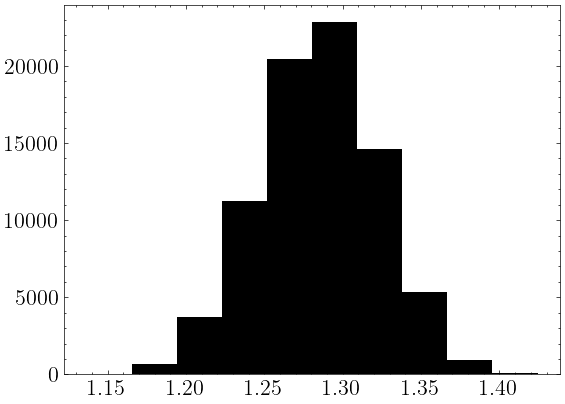

In [119]:
plt.hist(z_116_c1_PIE_logt_rec)

In [120]:
get_quantiles(z_116_c1_PIE_logt_rec)

1.29 -0.04 0.04


(array([   41.,   542.,  3802., 14185., 24421., 21922., 11441.,  3049.,
          535.,    62.]),
 array([0.88409219, 0.88788924, 0.8916863 , 0.89548336, 0.89928042,
        0.90307748, 0.90687454, 0.9106716 , 0.91446865, 0.91826571,
        0.92206277]),
 <BarContainer object of 10 artists>)

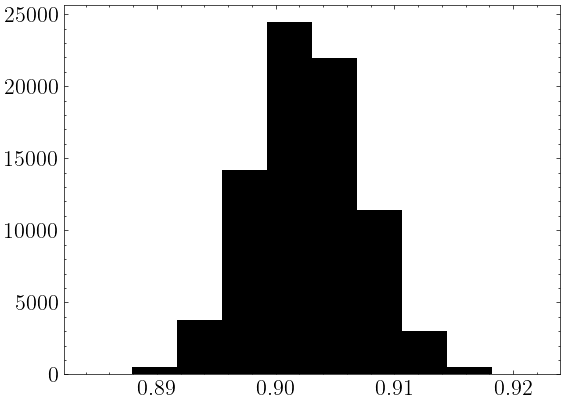

In [121]:
plt.hist(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

In [122]:
get_quantiles(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

0.9 -0.0 0.0


In [123]:
np.median(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec)

0.9026380980130169

In [124]:
np.percentile(z_116_c1_PIE_logt_cool-z_116_c1_PIE_logt_rec,100*cdf_1sig)

0.9074114888201384

## c2

In [125]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/one_phase_c2.csv')

In [126]:
z_116_c2_PIE_logT, z_116_c2_PIE_logt_rec, z_116_c2_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens'],
                                                                                    z_116_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([2.4000e+01, 1.9500e+02, 1.1300e+03, 5.0330e+03, 1.5233e+04,
        2.4208e+04, 2.3814e+04, 8.9300e+03, 1.3830e+03, 5.0000e+01]),
 array([4.41637232, 4.44598339, 4.47559446, 4.50520554, 4.53481661,
        4.56442768, 4.59403876, 4.62364983, 4.65326091, 4.68287198,
        4.71248305]),
 <BarContainer object of 10 artists>)

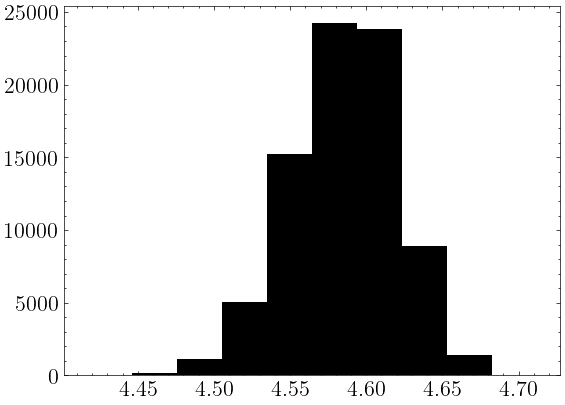

In [127]:
plt.hist(z_116_c2_PIE_logT)

In [128]:
get_quantiles(z_116_c2_PIE_logT)

4.59 -0.04 0.03


(array([8.5000e+01, 9.7700e+02, 5.4290e+03, 1.6329e+04, 2.5443e+04,
        2.0641e+04, 8.6540e+03, 2.1520e+03, 2.7900e+02, 1.1000e+01]),
 array([1.6229106 , 1.73649212, 1.85007365, 1.96365517, 2.07723669,
        2.19081822, 2.30439974, 2.41798126, 2.53156279, 2.64514431,
        2.75872583]),
 <BarContainer object of 10 artists>)

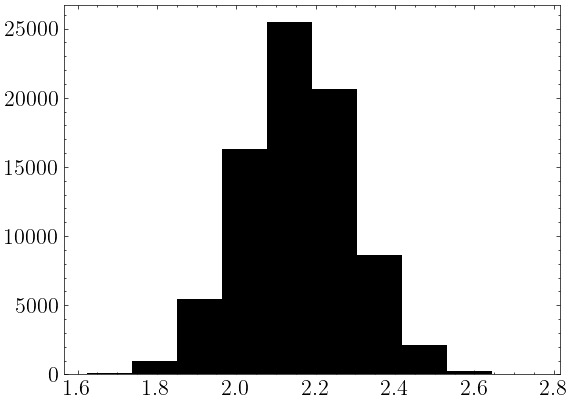

In [129]:
plt.hist(z_116_c2_PIE_logt_rec)

In [130]:
get_quantiles(z_116_c2_PIE_logt_rec)

2.15 -0.14 0.14


(array([2.0000e+01, 1.8100e+02, 9.4700e+02, 4.0620e+03, 1.3239e+04,
        2.2912e+04, 2.5616e+04, 1.1199e+04, 1.7660e+03, 5.8000e+01]),
 array([0.8316801 , 0.86053191, 0.88938372, 0.91823552, 0.94708733,
        0.97593914, 1.00479095, 1.03364275, 1.06249456, 1.09134637,
        1.12019818]),
 <BarContainer object of 10 artists>)

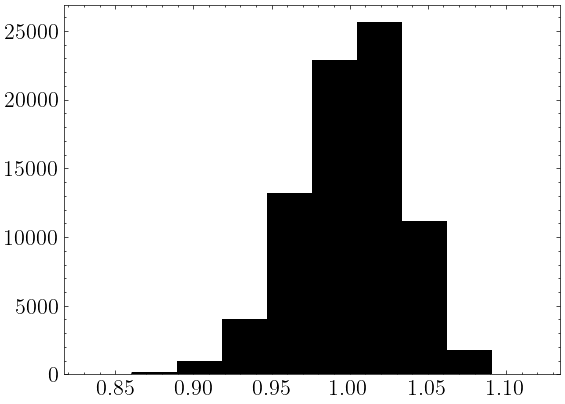

In [131]:
plt.hist(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

In [132]:
get_quantiles(z_116_c2_PIE_logt_cool-z_116_c2_PIE_logt_rec)

1.0 -0.04 0.03


## c2

In [133]:
z_116_c2_PIE_samples = pd.read_csv(loaddir+'z=1.16590953/cloudy_fits/two_phase_c2.csv')

### c2H

In [134]:
z_116_c2H_PIE_logT, z_116_c2H_PIE_logt_rec, z_116_c2H_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens_p1'],
                                                                                             z_116_c2_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  116.,   859.,  3707., 12613., 28881., 46961., 46457., 29548.,
         9897.,  1361.]),
 array([4.34792438, 4.38022588, 4.41252739, 4.4448289 , 4.47713041,
        4.50943191, 4.54173342, 4.57403493, 4.60633643, 4.63863794,
        4.67093945]),
 <BarContainer object of 10 artists>)

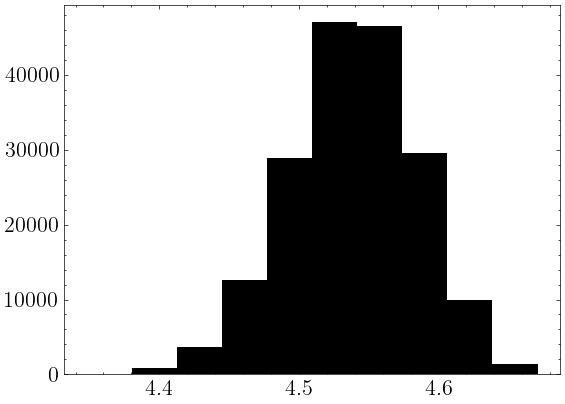

In [135]:
plt.hist(z_116_c2H_PIE_logT)

In [136]:
get_quantiles(z_116_c2H_PIE_logT)

4.54 -0.05 0.04


(array([1.9000e+01, 3.1300e+02, 3.1330e+03, 1.4286e+04, 3.6951e+04,
        4.6342e+04, 4.6062e+04, 2.6597e+04, 6.3340e+03, 3.6300e+02]),
 array([0.8846553 , 1.04878019, 1.21290508, 1.37702997, 1.54115487,
        1.70527976, 1.86940465, 2.03352954, 2.19765443, 2.36177933,
        2.52590422]),
 <BarContainer object of 10 artists>)

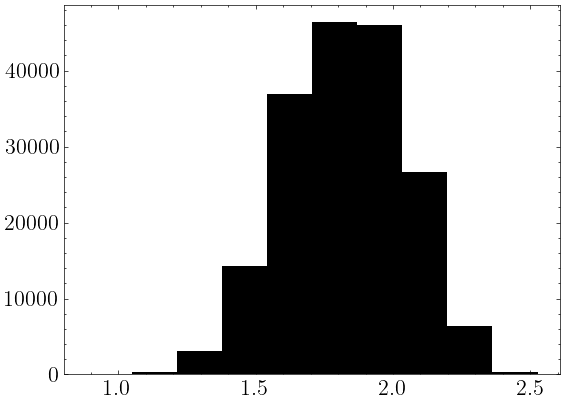

In [137]:
plt.hist(z_116_c2H_PIE_logt_rec)

In [138]:
get_quantiles(z_116_c2H_PIE_logt_rec)

1.84 -0.24 0.22


(array([   64.,   742.,  3610., 11712., 29380., 51031., 46466., 27724.,
         8505.,  1166.]),
 array([0.79187603, 0.82198526, 0.8520945 , 0.88220374, 0.91231298,
        0.94242221, 0.97253145, 1.00264069, 1.03274993, 1.06285917,
        1.0929684 ]),
 <BarContainer object of 10 artists>)

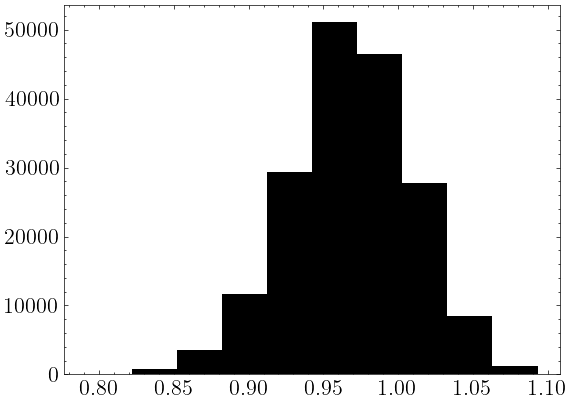

In [139]:
plt.hist(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec)

In [140]:
get_quantiles(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec)

0.97 -0.04 0.04


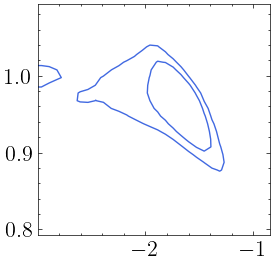

In [141]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p1']), 
              np.array(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='royalblue')

### c2L

In [142]:
z_116_c2L_PIE_logT, z_116_c2L_PIE_logt_rec, z_116_c2L_PIE_logt_cool = get_cooling_dist(z_116_c2_PIE_samples['log_hdens_p2'],
                                                                                             z_116_c2_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([1.8000e+01, 3.6000e+01, 2.8900e+02, 1.6130e+03, 6.6180e+03,
        1.8457e+04, 4.2516e+04, 5.6780e+04, 4.3287e+04, 1.0786e+04]),
 array([4.18244653, 4.24078859, 4.29913064, 4.3574727 , 4.41581475,
        4.47415681, 4.53249886, 4.59084092, 4.64918297, 4.70752503,
        4.76586708]),
 <BarContainer object of 10 artists>)

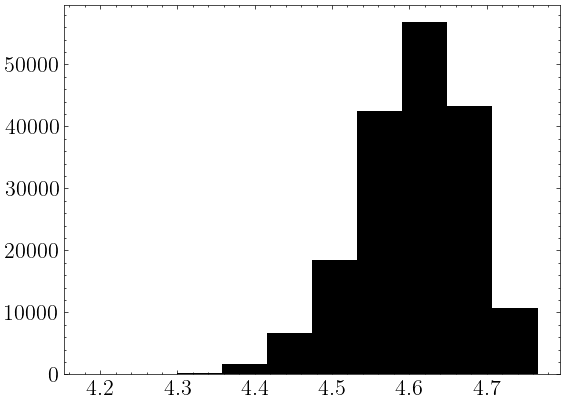

In [143]:
plt.hist(z_116_c2L_PIE_logT)

In [144]:
get_quantiles(z_116_c2L_PIE_logT)

4.61 -0.08 0.06


(array([  529.,  7908., 33340., 48068., 37381., 22541., 13304.,  8898.,
         5306.,  3125.]),
 array([1.72482788, 1.88423651, 2.04364515, 2.20305378, 2.36246242,
        2.52187106, 2.68127969, 2.84068833, 3.00009696, 3.1595056 ,
        3.31891423]),
 <BarContainer object of 10 artists>)

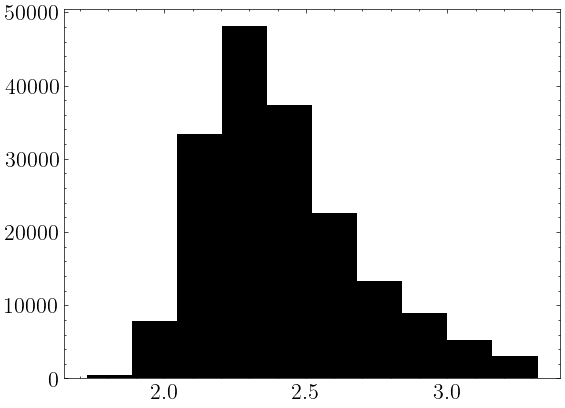

In [145]:
plt.hist(z_116_c2L_PIE_logt_rec)

In [146]:
get_quantiles(z_116_c2L_PIE_logt_rec)

2.36 -0.21 0.34


(array([2.0000e+01, 1.5000e+01, 6.9000e+01, 1.5500e+02, 4.8600e+02,
        1.5000e+03, 5.6360e+03, 2.4744e+04, 8.9007e+04, 5.8768e+04]),
 array([-0.05405044,  0.06788097,  0.18981237,  0.31174378,  0.43367518,
         0.55560659,  0.677538  ,  0.7994694 ,  0.92140081,  1.04333222,
         1.16526362]),
 <BarContainer object of 10 artists>)

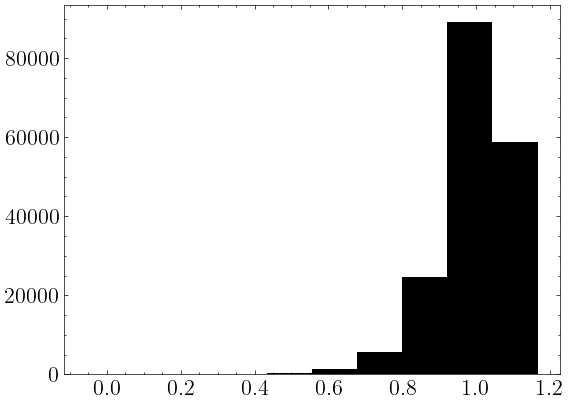

In [147]:
plt.hist(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec)

In [148]:
get_quantiles(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec)

1.01 -0.1 0.06


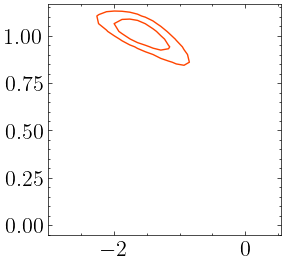

In [149]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p2']), 
              np.array(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

# z=1.22, PIE

## c1

In [150]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22541394/cloudy_fits/one_phase.csv')

In [151]:
z_122_c1_PIE_logT, z_122_c1_PIE_logt_rec, z_122_c1_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens'],
                                                                                    z_122_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([3.0000e+00, 4.9000e+01, 3.3200e+02, 2.5930e+03, 1.1501e+04,
        2.8373e+04, 2.6431e+04, 9.2800e+03, 1.3540e+03, 8.4000e+01]),
 array([4.44534055, 4.45702811, 4.46871567, 4.48040324, 4.4920908 ,
        4.50377836, 4.51546592, 4.52715348, 4.53884105, 4.55052861,
        4.56221617]),
 <BarContainer object of 10 artists>)

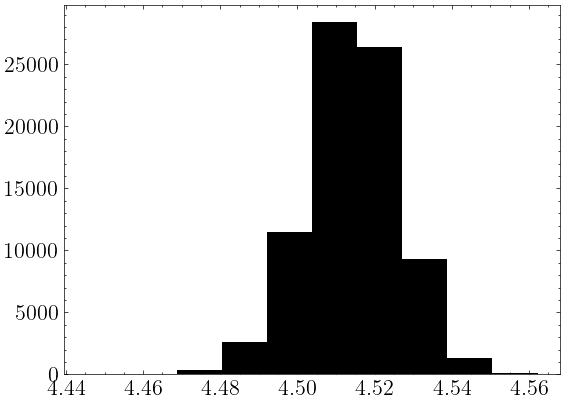

In [152]:
plt.hist(z_122_c1_PIE_logT)

In [153]:
get_quantiles(z_122_c1_PIE_logT)

4.51 -0.01 0.01


(array([4.0000e+00, 8.0000e+01, 9.5000e+02, 7.0080e+03, 2.2692e+04,
        3.1378e+04, 1.4594e+04, 3.0650e+03, 2.2000e+02, 9.0000e+00]),
 array([2.19208865, 2.23977302, 2.28745738, 2.33514174, 2.38282611,
        2.43051047, 2.47819483, 2.5258792 , 2.57356356, 2.62124792,
        2.66893228]),
 <BarContainer object of 10 artists>)

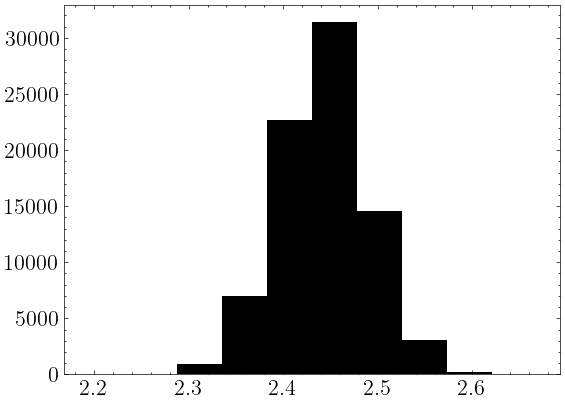

In [154]:
plt.hist(z_122_c1_PIE_logt_rec)

In [155]:
get_quantiles(z_122_c1_PIE_logt_rec)

2.44 -0.05 0.05


(array([3.1000e+01, 2.6100e+02, 1.5310e+03, 8.0610e+03, 2.3477e+04,
        2.8836e+04, 1.4466e+04, 3.0710e+03, 2.4900e+02, 1.7000e+01]),
 array([0.77628841, 0.78870577, 0.80112314, 0.8135405 , 0.82595786,
        0.83837522, 0.85079258, 0.86320994, 0.8756273 , 0.88804466,
        0.90046202]),
 <BarContainer object of 10 artists>)

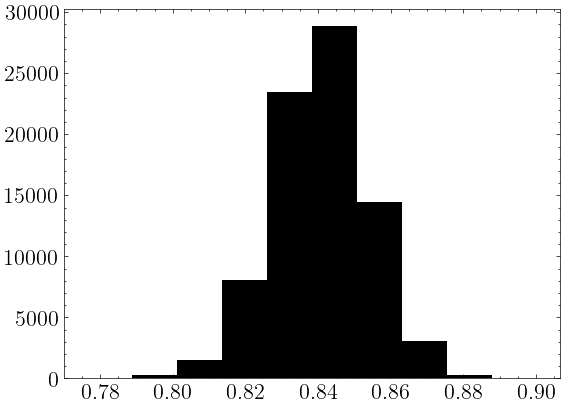

In [156]:
plt.hist(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

In [157]:
get_quantiles(z_122_c1_PIE_logt_cool-z_122_c1_PIE_logt_rec)

0.84 -0.01 0.01


## c1

In [158]:
z_122_c1_PIE_samples = pd.read_csv(loaddir+'z=1.22541394/cloudy_fits/two_phase.csv')

### c1H

In [159]:
z_122_c1H_PIE_logT, z_122_c1H_PIE_logt_rec, z_122_c1H_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens_p1'],
                                                                                             z_122_c1_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([   63.,   887.,  1737.,  4071.,  5083.,  9786., 18007., 23247.,
        15289.,  1830.]),
 array([3.62525771, 3.72606588, 3.82687405, 3.92768221, 4.02849038,
        4.12929855, 4.23010672, 4.33091489, 4.43172306, 4.53253122,
        4.63333939]),
 <BarContainer object of 10 artists>)

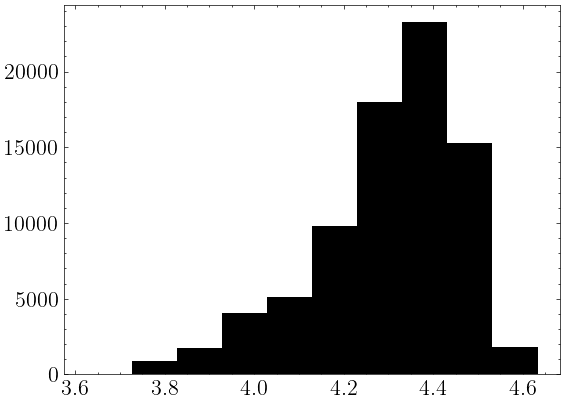

In [160]:
plt.hist(z_122_c1H_PIE_logT)

In [161]:
get_quantiles(z_122_c1H_PIE_logT)

4.33 -0.19 0.12


In [162]:
np.median(z_122_c1H_PIE_logT)-np.percentile(z_122_c1H_PIE_logT, 100*(1-cdf_1sig))

0.19179784413551904

(array([  851.,   547.,   338.,   489.,  1155.,  3713., 17790., 31169.,
        18565.,  5383.]),
 array([-3.32726363, -2.74696122, -2.16665881, -1.5863564 , -1.00605399,
        -0.42575158,  0.15455083,  0.73485324,  1.31515565,  1.89545807,
         2.47576048]),
 <BarContainer object of 10 artists>)

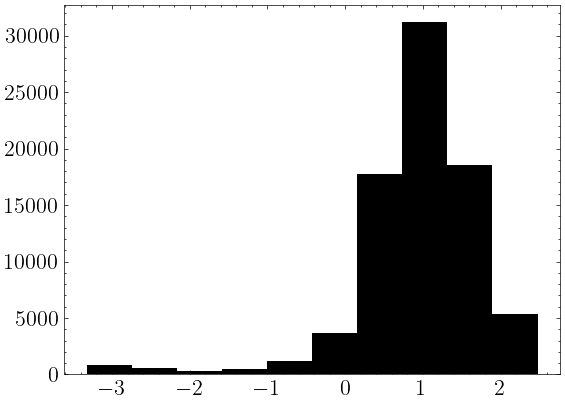

In [163]:
plt.hist(z_122_c1H_PIE_logt_rec)

In [164]:
get_quantiles(z_122_c1H_PIE_logt_rec)

1.0 -0.56 0.61


(array([  211.,   318.,   499.,   695.,  3616., 24937., 48623.,   449.,
          254.,   398.]),
 array([-0.49156047, -0.27679171, -0.06202294,  0.15274583,  0.3675146 ,
         0.58228337,  0.79705213,  1.0118209 ,  1.22658967,  1.44135844,
         1.65612721]),
 <BarContainer object of 10 artists>)

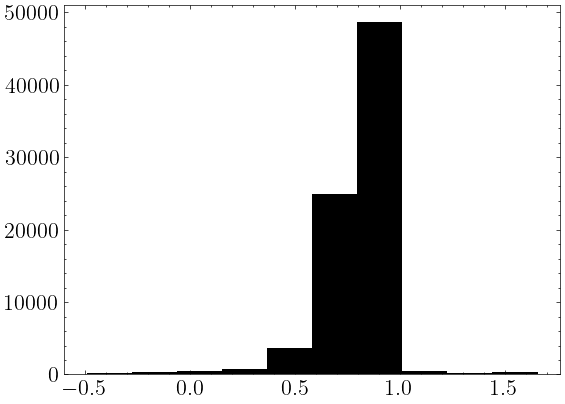

In [165]:
plt.hist(z_122_c1H_PIE_logt_cool-z_122_c1H_PIE_logt_rec)

In [166]:
get_quantiles(z_122_c1H_PIE_logt_cool-z_122_c1H_PIE_logt_rec)

0.83 -0.14 0.07


### c1L

In [167]:
z_122_c1L_PIE_logT, z_122_c1L_PIE_logt_rec, z_122_c1L_PIE_logt_cool = get_cooling_dist(z_122_c1_PIE_samples['log_hdens_p2'],
                                                                                             z_122_c1_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([2.9000e+01, 1.9320e+03, 2.1888e+04, 2.9621e+04, 1.6603e+04,
        6.5890e+03, 1.7770e+03, 9.0000e+02, 4.4400e+02, 2.1700e+02]),
 array([4.15095313, 4.20999298, 4.26903284, 4.32807269, 4.38711254,
        4.4461524 , 4.50519225, 4.56423211, 4.62327196, 4.68231182,
        4.74135167]),
 <BarContainer object of 10 artists>)

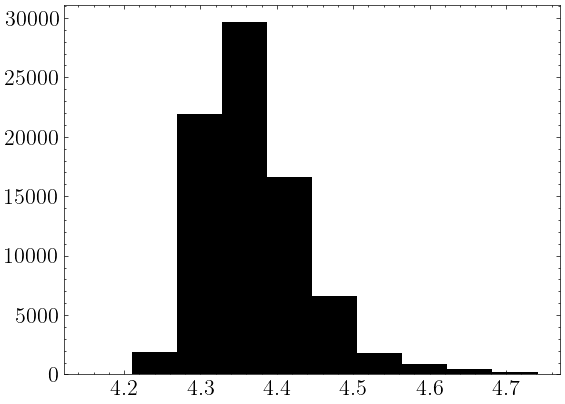

In [168]:
plt.hist(z_122_c1L_PIE_logT)

In [169]:
get_quantiles(z_122_c1L_PIE_logT)

4.36 -0.05 0.08


(array([ 1604., 32084., 30422.,  9022.,  3798.,  1508.,   623.,   508.,
          228.,   203.]),
 array([2.08065345, 2.2032331 , 2.32581276, 2.44839241, 2.57097206,
        2.69355172, 2.81613137, 2.93871102, 3.06129067, 3.18387033,
        3.30644998]),
 <BarContainer object of 10 artists>)

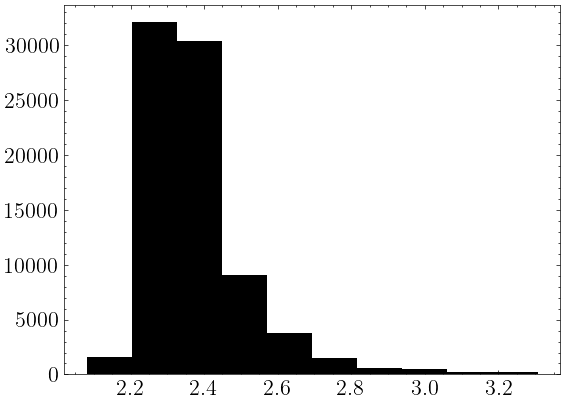

In [170]:
plt.hist(z_122_c1L_PIE_logt_rec)

In [171]:
get_quantiles(z_122_c1L_PIE_logt_rec)

2.34 -0.08 0.13


In [172]:
np.percentile(z_122_c1L_PIE_logt_rec, 100*cdf_1sig)-np.median(z_122_c1L_PIE_logt_rec)

0.13353987693565283

(array([ 2257.,  4590.,  5995.,  8951., 12471., 16230., 15257., 10278.,
         3483.,   488.]),
 array([-0.37697724, -0.24216531, -0.10735338,  0.02745855,  0.16227048,
         0.2970824 ,  0.43189433,  0.56670626,  0.70151819,  0.83633012,
         0.97114205]),
 <BarContainer object of 10 artists>)

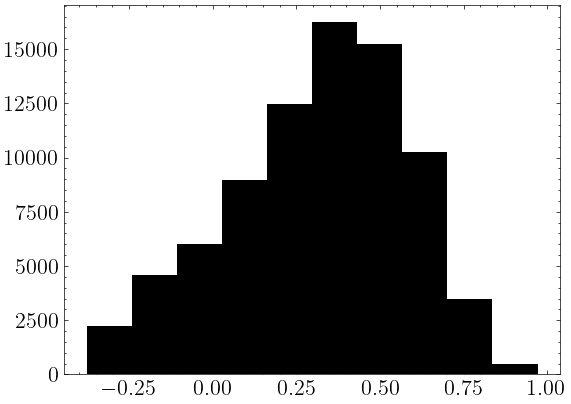

In [173]:
plt.hist(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

In [174]:
get_quantiles(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

0.35 -0.32 0.24


In [175]:
np.median(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec)

0.345261482661102

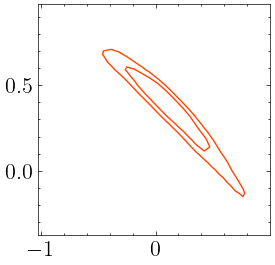

In [176]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_122_c1_PIE_samples['log_metals_p2']), 
              np.array(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

# z=1.26, PIE

## c1

In [177]:
z_126_c1_PIE_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/one_phase_c1.csv')

In [178]:
z_126_c1_PIE_logT, z_126_c1_PIE_logt_rec, z_126_c1_PIE_logt_cool = get_cooling_dist(z_126_c1_PIE_samples['log_hdens'],
                                                                                    z_126_c1_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([4.7090e+03, 1.0369e+04, 1.0799e+04, 9.8290e+03, 8.6330e+03,
        9.1360e+03, 2.6178e+04, 2.4400e+02, 8.0000e+01, 2.3000e+01]),
 array([3.64959434, 3.70570945, 3.76182455, 3.81793965, 3.87405476,
        3.93016986, 3.98628496, 4.04240007, 4.09851517, 4.15463027,
        4.21074537]),
 <BarContainer object of 10 artists>)

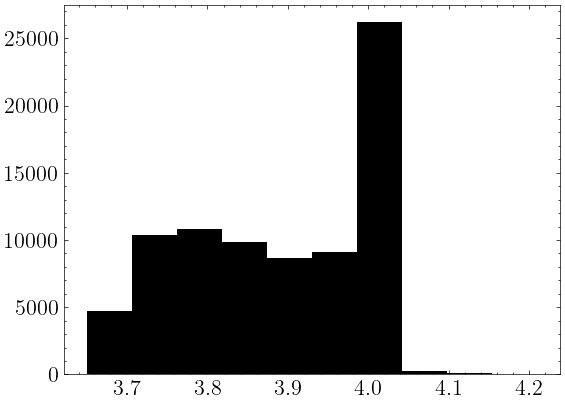

In [179]:
plt.hist(z_126_c1_PIE_logT)

In [180]:
get_quantiles(z_126_c1_PIE_logT), np.percentile(z_126_c1_PIE_logT, 100*cdf_3sig)

3.9 -0.15 0.1


(None, 4.095827272593515)

(array([9.2600e+02, 4.3450e+03, 1.0212e+04, 3.4735e+04, 1.9632e+04,
        6.8760e+03, 2.4400e+03, 6.9000e+02, 1.2900e+02, 1.5000e+01]),
 array([0.72999532, 0.81751554, 0.90503577, 0.99255599, 1.08007621,
        1.16759644, 1.25511666, 1.34263688, 1.43015711, 1.51767733,
        1.60519755]),
 <BarContainer object of 10 artists>)

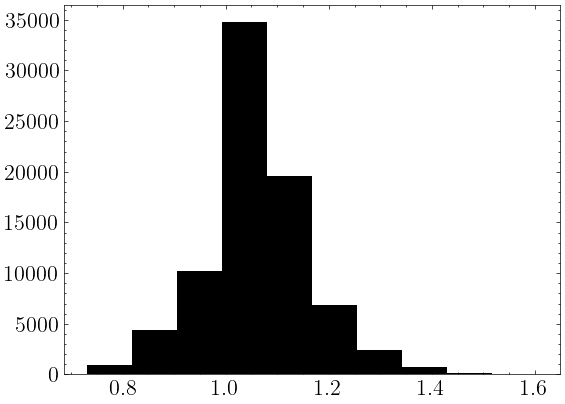

In [181]:
plt.hist(z_126_c1_PIE_logt_rec)

In [182]:
get_quantiles(z_126_c1_PIE_logt_rec)

1.06 -0.09 0.08


(array([  703.,  3516.,  8098., 24799., 28027.,  9708.,  3220.,  1441.,
          414.,    74.]),
 array([-0.45110817, -0.35373242, -0.25635666, -0.15898091, -0.06160515,
         0.0357706 ,  0.13314635,  0.23052211,  0.32789786,  0.42527362,
         0.52264937]),
 <BarContainer object of 10 artists>)

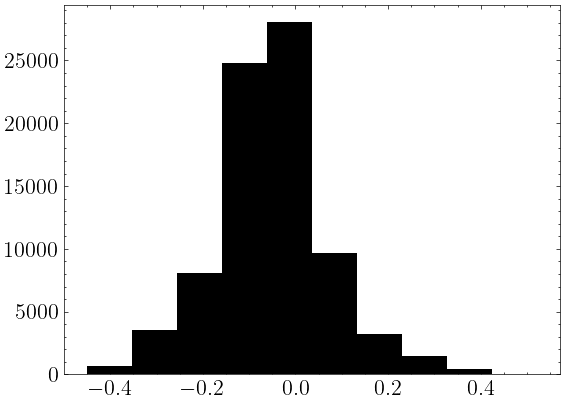

In [183]:
plt.hist(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

In [184]:
get_quantiles(z_126_c1_PIE_logt_cool-z_126_c1_PIE_logt_rec)

-0.06 -0.1 0.1


# z=1.27, PIE

## c1

In [185]:
z_127_c1_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/two_phase_c1.csv')

### c1H

In [186]:
z_127_c1H_PIE_logT, z_127_c1H_PIE_logt_rec, z_127_c1H_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens_p1'],
                                                                                       z_127_c1_PIE_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([ 9370., 25817., 20008., 16471., 22150., 23711., 33900., 24801.,
         3625.,   147.]),
 array([3.75060949, 3.81073059, 3.87085169, 3.93097279, 3.99109389,
        4.051215  , 4.1113361 , 4.1714572 , 4.2315783 , 4.2916994 ,
        4.3518205 ]),
 <BarContainer object of 10 artists>)

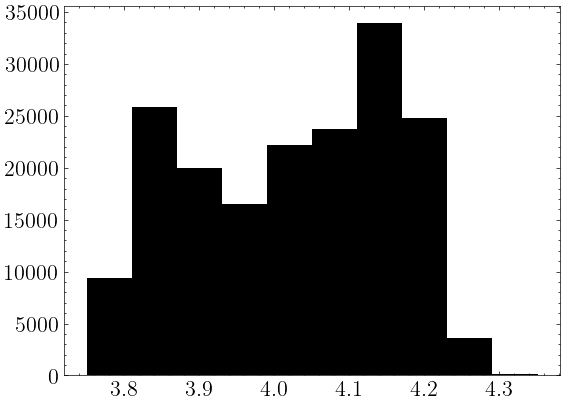

In [187]:
plt.hist(z_127_c1H_PIE_logT)

In [188]:
get_quantiles(z_127_c1H_PIE_logT)

4.04 -0.18 0.13


(array([  163.,  2337., 14294., 31256., 26239., 25064., 23986., 31197.,
        23995.,  1469.]),
 array([-0.62589812, -0.39458627, -0.16327441,  0.06803744,  0.29934929,
         0.53066115,  0.761973  ,  0.99328486,  1.22459671,  1.45590857,
         1.68722042]),
 <BarContainer object of 10 artists>)

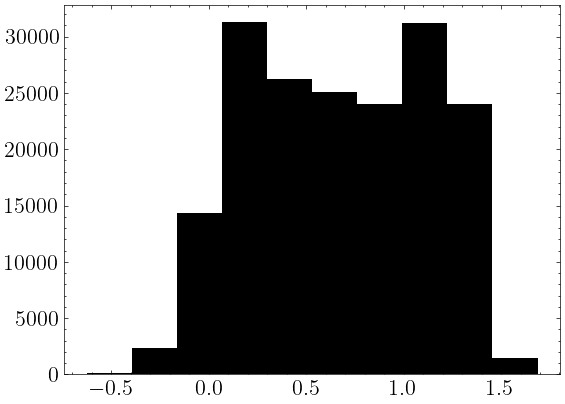

In [189]:
plt.hist(z_127_c1H_PIE_logt_rec)

In [190]:
get_quantiles(z_127_c1H_PIE_logt_rec)

0.68 -0.52 0.53


(array([  289.,   712.,  1335.,  2685.,  5757., 15208., 28975., 70982.,
        52866.,  1191.]),
 array([-0.42915799, -0.30539514, -0.18163228, -0.05786943,  0.06589343,
         0.18965629,  0.31341914,  0.437182  ,  0.56094485,  0.68470771,
         0.80847057]),
 <BarContainer object of 10 artists>)

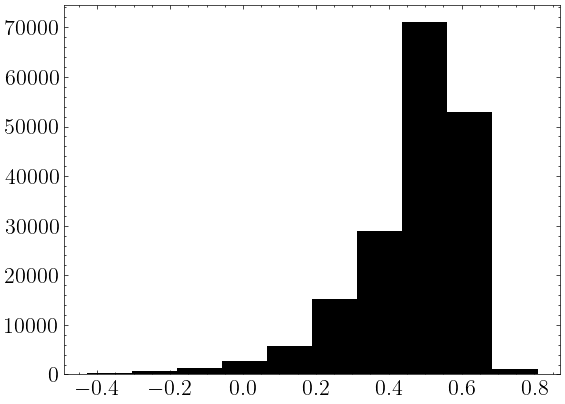

In [191]:
plt.hist(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

In [192]:
get_quantiles(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

0.52 -0.19 0.08


### c1L

In [193]:
z_127_c1L_PIE_logT, z_127_c1L_PIE_logt_rec, z_127_c1L_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_samples['log_hdens_p2'],
                                                                                       z_127_c1_PIE_samples['log_metals_p2'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([5.0000e+00, 6.7000e+01, 7.9400e+02, 3.8210e+03, 1.3908e+04,
        3.9453e+04, 6.8559e+04, 4.0034e+04, 1.2401e+04, 9.5800e+02]),
 array([3.96072829, 4.00924604, 4.05776378, 4.10628153, 4.15479928,
        4.20331703, 4.25183477, 4.30035252, 4.34887027, 4.39738802,
        4.44590577]),
 <BarContainer object of 10 artists>)

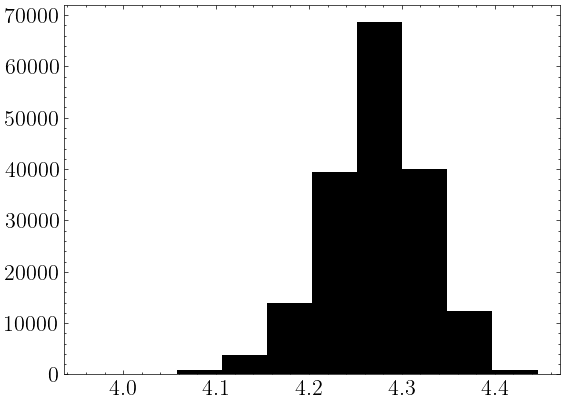

In [194]:
plt.hist(z_127_c1L_PIE_logT)

In [195]:
get_quantiles(z_127_c1L_PIE_logT)

4.27 -0.05 0.05


(array([  156.,  1978., 12536., 36860., 52708., 42970., 21506.,  9285.,
         1841.,   160.]),
 array([1.84303261, 1.92039597, 1.99775934, 2.07512271, 2.15248607,
        2.22984944, 2.30721281, 2.38457617, 2.46193954, 2.53930291,
        2.61666628]),
 <BarContainer object of 10 artists>)

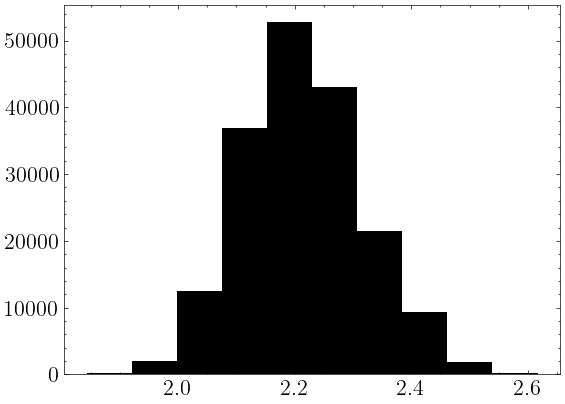

In [196]:
plt.hist(z_127_c1L_PIE_logt_rec)

In [197]:
get_quantiles(z_127_c1L_PIE_logt_rec)

2.21 -0.1 0.11


(array([ 7266., 15364., 21686., 28846., 33814., 34420., 23291., 12308.,
         2808.,   197.]),
 array([-0.39554496, -0.29369943, -0.19185389, -0.09000835,  0.01183718,
         0.11368272,  0.21552826,  0.31737379,  0.41921933,  0.52106487,
         0.6229104 ]),
 <BarContainer object of 10 artists>)

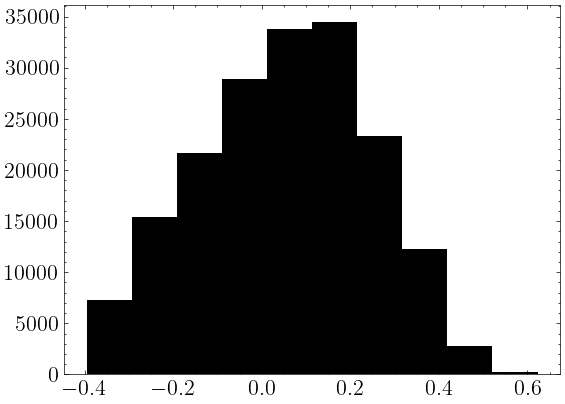

In [198]:
plt.hist(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec)

In [199]:
get_quantiles(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec)

0.06 -0.22 0.19


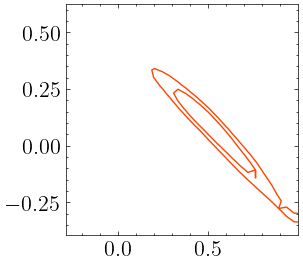

In [200]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_127_c1_PIE_samples['log_metals_p2']), 
              np.array(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

## c2

In [201]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/one_phase_c2.csv')

In [202]:
z_127_c2_PIE_logT, z_127_c2_PIE_logt_rec, z_127_c2_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens'],
                                                                                    z_127_c2_PIE_samples['log_metals'],
                                                                                    logq_rec_interp, logt_cool_interp)

(array([   38.,   195.,  1119.,  4986., 16274., 26467., 21267.,  8143.,
         1395.,   116.]),
 array([4.29161578, 4.30963124, 4.3276467 , 4.34566216, 4.36367763,
        4.38169309, 4.39970855, 4.41772401, 4.43573948, 4.45375494,
        4.4717704 ]),
 <BarContainer object of 10 artists>)

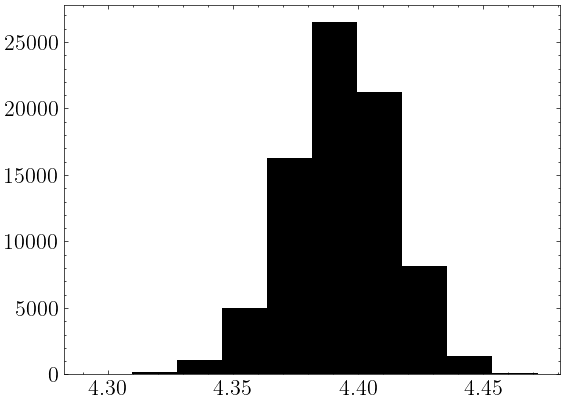

In [203]:
plt.hist(z_127_c2_PIE_logT)

In [204]:
get_quantiles(z_127_c2_PIE_logT)

4.39 -0.02 0.02


(array([   76.,   548.,  2984., 11684., 21817., 23673., 13851.,  4459.,
          839.,    69.]),
 array([1.8764294 , 1.92759044, 1.97875147, 2.02991251, 2.08107354,
        2.13223458, 2.18339561, 2.23455665, 2.28571768, 2.33687872,
        2.38803975]),
 <BarContainer object of 10 artists>)

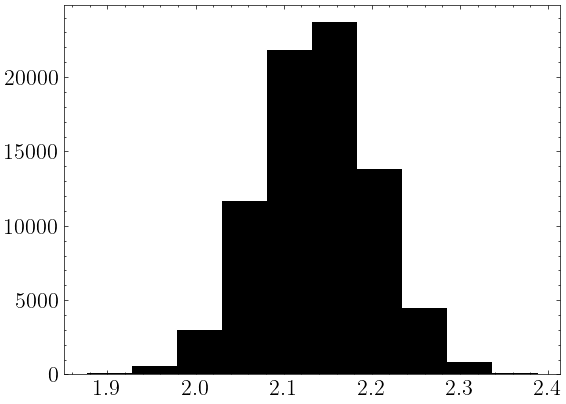

In [205]:
plt.hist(z_127_c2_PIE_logt_rec)

In [206]:
get_quantiles(z_127_c2_PIE_logt_rec)

2.14 -0.06 0.06


(array([   27.,   135.,  1012.,  5189., 16379., 25852., 21049.,  8835.,
         1417.,   105.]),
 array([0.56364492, 0.58505363, 0.60646234, 0.62787105, 0.64927976,
        0.67068847, 0.69209718, 0.71350589, 0.7349146 , 0.75632331,
        0.77773202]),
 <BarContainer object of 10 artists>)

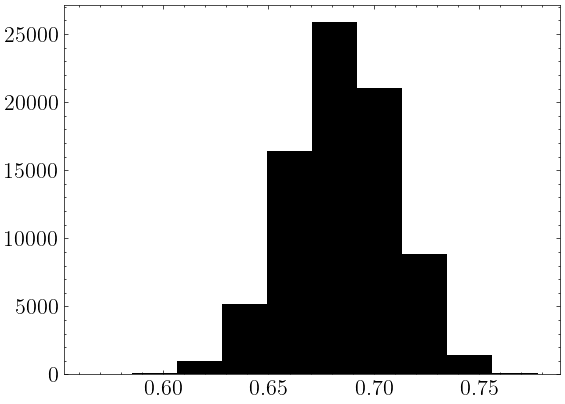

In [207]:
plt.hist(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

In [208]:
get_quantiles(z_127_c2_PIE_logt_cool-z_127_c2_PIE_logt_rec)

0.69 -0.03 0.02


## c2

In [209]:
z_127_c2_PIE_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/two_phase_c2.csv')

### c2H

In [210]:
z_127_c2H_PIE_logT, z_127_c2H_PIE_logt_rec, z_127_c2H_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens_p1'],
                                                                                             z_127_c2_PIE_samples['log_metals_p1'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  432.,  5669., 19855., 29471., 31410., 27810., 29377., 27307.,
         8156.,   513.]),
 array([4.1678118 , 4.21209034, 4.25636888, 4.30064742, 4.34492596,
        4.38920449, 4.43348303, 4.47776157, 4.52204011, 4.56631865,
        4.61059719]),
 <BarContainer object of 10 artists>)

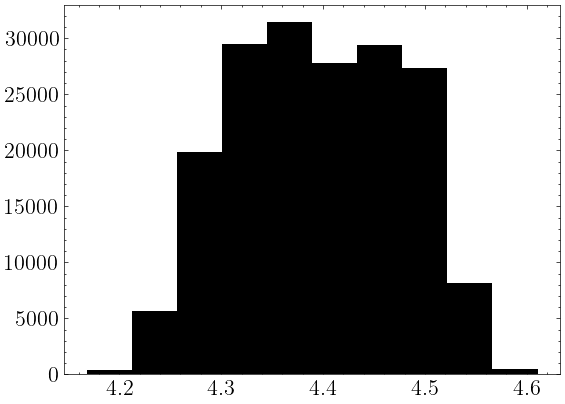

In [211]:
plt.hist(z_127_c2H_PIE_logT)

In [212]:
get_quantiles(z_127_c2H_PIE_logT)

4.39 -0.09 0.09


(array([10669., 47530., 44695., 33457., 20137., 12288.,  7373.,  3173.,
          617.,    61.]),
 array([1.30082458, 1.40312561, 1.50542663, 1.60772766, 1.71002869,
        1.81232972, 1.91463075, 2.01693177, 2.1192328 , 2.22153383,
        2.32383486]),
 <BarContainer object of 10 artists>)

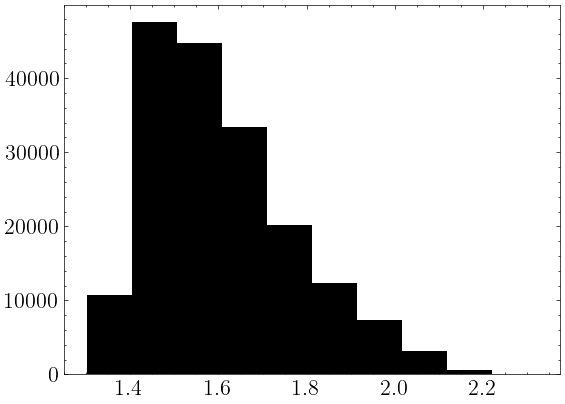

In [213]:
plt.hist(z_127_c2H_PIE_logt_rec)

In [214]:
get_quantiles(z_127_c2H_PIE_logt_rec)

1.57 -0.13 0.21


(array([  631.,  6577., 20623., 28083., 24826., 21482., 22754., 29797.,
        23591.,  1636.]),
 array([0.51458465, 0.56707301, 0.61956137, 0.67204973, 0.72453809,
        0.77702645, 0.82951481, 0.88200317, 0.93449153, 0.98697989,
        1.03946825]),
 <BarContainer object of 10 artists>)

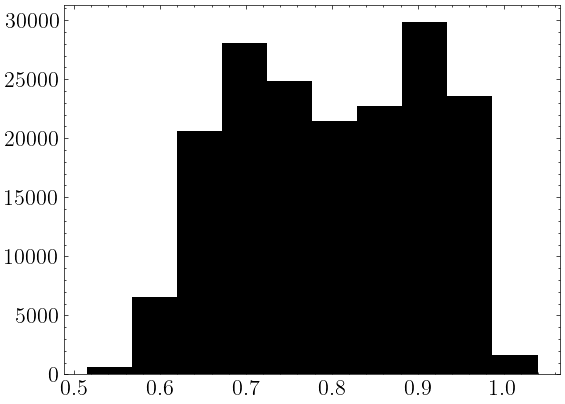

In [215]:
plt.hist(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec)

In [216]:
get_quantiles(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec)

0.8 -0.13 0.13


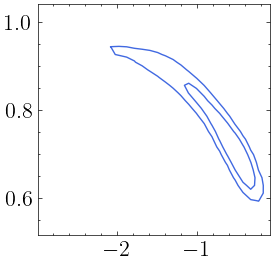

In [217]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p1']), 
              np.array(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='royalblue')

### c2L

In [218]:
z_127_c2L_PIE_logT, z_127_c2L_PIE_logt_rec, z_127_c2L_PIE_logt_cool = get_cooling_dist(z_127_c2_PIE_samples['log_hdens_p2'],
                                                                                             z_127_c2_PIE_samples['log_metals_p2'],
                                                                                             logq_rec_interp, logt_cool_interp)

(array([  375.,  2063., 12832., 47679., 59944., 33845., 14898.,  5277.,
         2619.,   468.]),
 array([3.92408371, 4.00458434, 4.08508498, 4.16558561, 4.24608625,
        4.32658688, 4.40708752, 4.48758815, 4.56808879, 4.64858943,
        4.72909006]),
 <BarContainer object of 10 artists>)

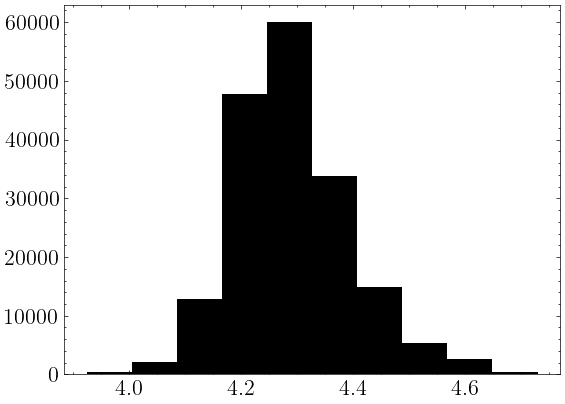

In [219]:
plt.hist(z_127_c2L_PIE_logT)

In [220]:
get_quantiles(z_127_c2L_PIE_logT)

4.28 -0.08 0.11


(array([ 4062., 57247., 61847., 29222., 14411.,  7851.,  3837.,   950.,
          427.,   146.]),
 array([1.77147157, 1.91857225, 2.06567293, 2.21277361, 2.35987429,
        2.50697497, 2.65407565, 2.80117633, 2.94827701, 3.09537769,
        3.24247837]),
 <BarContainer object of 10 artists>)

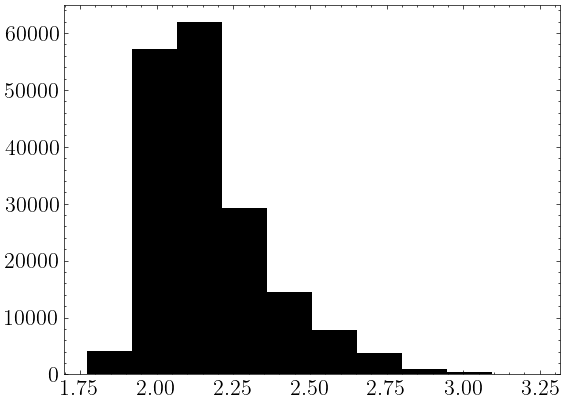

In [221]:
plt.hist(z_127_c2L_PIE_logt_rec)

In [222]:
get_quantiles(z_127_c2L_PIE_logt_rec)

2.12 -0.11 0.23


(array([ 1529.,  5480., 16665., 33636., 43970., 41711., 23618.,  9153.,
         3231.,  1007.]),
 array([-0.40327891, -0.25313298, -0.10298704,  0.04715889,  0.19730482,
         0.34745075,  0.49759668,  0.64774262,  0.79788855,  0.94803448,
         1.09818041]),
 <BarContainer object of 10 artists>)

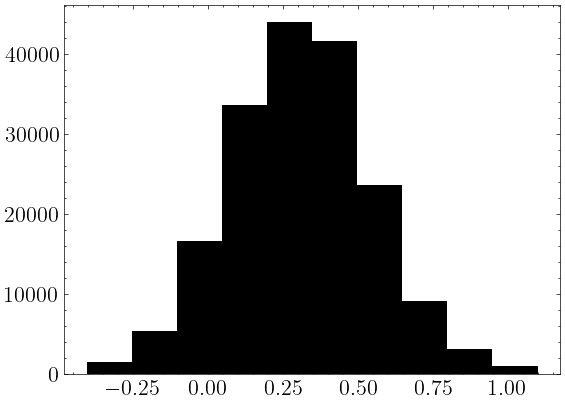

In [223]:
plt.hist(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec)

In [224]:
get_quantiles(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec)

0.31 -0.24 0.22


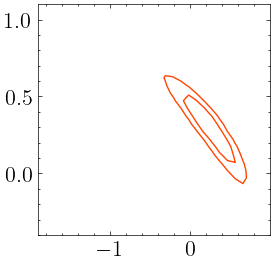

In [225]:
fig, ax = plt.subplots(1,figsize=(3,3))

corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p2']), 
              np.array(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[1-np.exp(-0.5),2*cdf_1sig-1], color='orangered')

# Summary plot

In [226]:
def plot_str(ax, s_x, s_y, dx_lim, dy_lim, m, c, mfc, a, c_dx, c_dy):
    
    '''
    Function to plot string
    
    ax: axis
    s_x, s_y: string for x, y
    dx_lim, dy_lim: arrow width for upper limit in x, y
    m: marker type
    c: marker color
    mfc: marker face color (can be empty)
    a: transparency
    c_dx, c_dy: scaling for bar connecting spear to marker (for upper limits)
    '''
    
    x_uplim = s_x[0]=='<'
    y_uplim = s_y[0]=='<'
    
    x_lolim = s_x[0]=='>'
    y_lolim = s_y[0]=='>'
    
    # Handle x
    # Limits
    if x_uplim or x_lolim:
        x = float(s_x[1:])
        dx = dx_lim
    # Detection
    else:
        s_x_split = s_x.split(',')
        x = float(s_x_split[0])
        dx_lo = -float(s_x_split[1]) # Take care of the negative sign
        dx_hi = float(s_x_split[2])
        
    # Handle y
    if y_uplim or y_lolim:
        y = float(s_y[1:])
        dy = dy_lim
    # Detection
    else:
        s_y_split = s_y.split(',')
        y = float(s_y_split[0])
        dy_lo = -float(s_y_split[1]) # Take care of the negative sign
        dy_hi = float(s_y_split[2])
        
    # Plot
    # x uplim
    if x_uplim:
        
        # y uplim
        if y_uplim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xuplims=True, uplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[c_dx*dx],[0]], yerr=[[c_dy*dy],[0]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y lolim
        elif y_lolim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xuplims=True, lolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[c_dx*dx],[0]], yerr=[[0],[c_dy*dy]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y det
        else:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=[[dy_lo],[dy_hi]], marker=m, xuplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)                                       
            caps[0].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[c_dx*dx],[0]], yerr=[[dy_lo],[dy_hi]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)  
        
    # x lolim
    elif x_lolim:
        
        # y uplim
        if y_uplim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xlolims=True, uplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[0],[c_dx*dx]], yerr=[[c_dy*dy],[0]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y lolim
        elif y_lolim:
            # Make marker and spears
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=dy, marker=m, xlolims=True, lolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)      
            caps[0].set_fillstyle('none')
            caps[2].set_fillstyle('none')
            # Make connections
            ax.errorbar(x, y, xerr=[[0],[c_dx*dx]], yerr=[[0],[c_dy*dy]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c) 
            
        # y det
        else:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=dx, yerr=[[dy_lo],[dy_hi]], marker=m, xlolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)                                       
            caps[0].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[0],[c_dx*dx]], yerr=[[dy_lo],[dy_hi]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)  
        
    # x det
    else:
        
        # y uplim
        if y_uplim:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=dy, marker=m, uplims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)     
            caps[2].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=[[c_dy*dy],[0]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)    
            
        # y lolim
        elif y_lolim:
            # Make marker and spear
            (_, caps, _) = ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=dy, marker=m, lolims=True,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a, elinewidth=0)     
            caps[2].set_fillstyle('none')
            # Make connection
            ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=[[0],[c_dy*dy]], markersize=0,alpha=a,
                       linestyle='none', capsize=0, color=c)    
            
        # y det
        else:    
            ax.errorbar(x, y, xerr=[[dx_lo],[dx_hi]], yerr=[[dy_lo],[dy_hi]], marker=m,
                       linestyle='none', capsize=4, color=c, markerfacecolor=mfc, alpha=a)    

In [227]:
log_metals_arr = ['-0.84, -0.05, +0.05',
                '<0.6',
                '-0.2, -0.1, +0.1',
                '0.1, -0.1, +0.1',
                '-0.5, -0.4, +0.2',
                '<1.0',
                '-0.6, -0.3, +0.2',
                '<0.5',
                '0.2, -0.1, +0.1',
                '<1.0',
                '<-1.1',
                '<0.2',
                '-1.85, -0.05, +0.05',
                '-1.1, -0.7, +0.5',
                '<1.0',
                '0.6, -0.1, +0.1',
                '0.0, -0.2, +0.3',
                '<1.0',
                '<-0.2',
                '<1.0']

log_tctr = ['0.78, -0.01, +0.01',
            '0.7, -0.2, +0.1',
            '0.55, -0.05, +0.05',
            '0.4, -0.1, +0.1',
            '0.7, -0.1, +0.1',
            '0.5, -0.4, +0.2',
            '0.74, -0.06, +0.06',
            '0.7, -0.2, +0.1',
            '0.4, -0.1, +0.1',
            '0.1, -0.3, +0.3',
            '0.97, -0.04, +0.04',
            '1.0, -0.1, +0.1',
            '0.90, -0.01, +0.01',
            '0.8, -0.1, +0.1',
            '0.4, -0.3, +0.2',
            '-0.1, -0.1, +0.1',
            '0.5, -0.2, +0.1',
            '0.1, -0.2, +0.2',
            '0.8, -0.1, +0.1',
            '0.3, -0.2, +0.2']

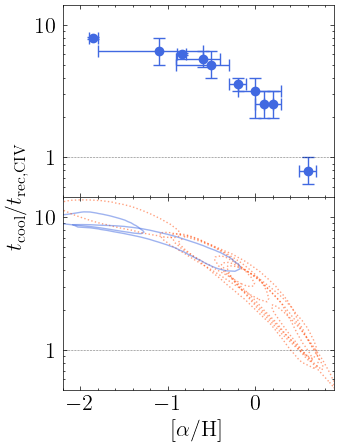

In [253]:
fig, axes = plt.subplots(2,1, figsize=(3.5,2.5*2), sharex=True, sharey=True)


for i in range(len(log_metals_arr)):
    if log_metals_arr[i][0]!='<':
        #m = float(log_metals_arr[i].split(',')[0])
        #if m == 0.6:
        #    a=1
        #else:
        #    a=.4
        plot_str(axes[0], log_metals_arr[i], log_tctr[i], .1, .08, 'o', 'royalblue', 'royalblue', 1, 1.8, 1.8)


# Phases without metallicity constraints

# z=0.67, c3L
corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c3L
corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.04, c4L
corner.hist2d(np.array(z_104_c4_PIE_samples['log_metals_p2']), 
              np.array(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})


# z=1.09, c1L
corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.16, c2H
corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p1']), 
              np.array(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='royalblue', contour_kwargs={'alpha':.5})

# z=1.16, c2L
corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p2']), 
              np.array(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})


# z=1.22, c1L
corner.hist2d(np.array(z_122_c1_PIE_samples['log_metals_p2']), 
              np.array(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

# z=1.27, c1L
corner.hist2d(np.array(z_127_c1_PIE_samples['log_metals_p2']), 
              np.array(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})


# z=1.27, c2H
corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p1']), 
              np.array(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='royalblue', contour_kwargs={'alpha':.5})

# z=1.27, c2L
corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p2']), 
              np.array(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.5, 'linestyles':'dotted'})

axes[0].axhline(0, linestyle=':', lw=.4)
axes[1].axhline(0, linestyle=':', lw=.4)


axes[1].set_xlabel(r'$\mathrm{[\alpha/H]}$')
#axes[1].set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec,CIV}$')

x = []

for i in [1e-2, 1e-1, 1e0, 1e1, 1e2]:
    for j in range(1,10):
        x.append(i*j)
        
axes[0].set_yticks(np.log10(x), minor=True)
axes[0].set_yticks([-1,0,1], labels=[r'$0.1$', r'$1$', r'$10$'])

axes[0].set_xlim(-2.2,.9)
axes[0].set_ylim(-0.3,1.15)

plt.subplots_adjust(wspace=0., hspace=0.)

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec,CIV}$', labelpad=25) # Use argument `labelpad` to move label downwards.

plt.savefig(rootdir+'Figures/metals_cool.pdf', dpi=300)
plt.savefig(rootdir+'Figures/metals_cool.png', dpi=300)

In [229]:
1-np.exp(-.5)

0.3934693402873666

(-0.5, 1.15)

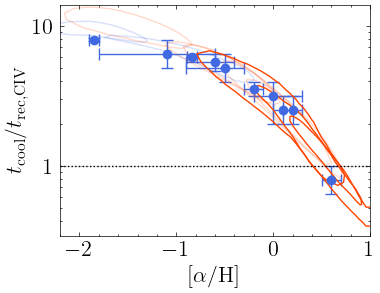

In [262]:
fig, ax = plt.subplots(1, figsize=(4,3))


for i in range(len(log_metals_arr)):
    if log_metals_arr[i][0]!='<':
        #m = float(log_metals_arr[i].split(',')[0])
        #if m == 0.6:
        #    a=1
        #else:
        #    a=.4
        plot_str(ax, log_metals_arr[i], log_tctr[i], .1, .08, 'o', 'royalblue', 'royalblue', 1, 1.8, 1.8)


# Phases without metallicity constraints

# z=0.67, c3L
corner.hist2d(np.array(z_067_c1_PIE_samples['log_metals_p2']), 
              np.array(z_067_c1L_PIE_logt_cool-z_067_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})

# z=1.04, c3L
corner.hist2d(np.array(z_104_c3_PIE_samples['log_metals_p2']), 
              np.array(z_104_c3L_PIE_logt_cool-z_104_c3L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered')

# z=1.04, c4L
corner.hist2d(np.array(z_104_c4_PIE_samples['log_metals_p2']), 
              np.array(z_104_c4L_PIE_logt_cool-z_104_c4L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})


# z=1.09, c1L
corner.hist2d(np.array(z_109_c1_PIE_samples['log_metals_p2']), 
              np.array(z_109_c1L_PIE_logt_cool-z_109_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered')

# z=1.16, c2H
corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p1']), 
              np.array(z_116_c2H_PIE_logt_cool-z_116_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='royalblue', contour_kwargs={'alpha':.2})

# z=1.16, c2L
corner.hist2d(np.array(z_116_c2_PIE_samples['log_metals_p2']), 
              np.array(z_116_c2L_PIE_logt_cool-z_116_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})


# z=1.22, c1L
corner.hist2d(np.array(z_122_c1_PIE_samples['log_metals_p2']), 
              np.array(z_122_c1L_PIE_logt_cool-z_122_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})

# z=1.27, c1L
corner.hist2d(np.array(z_127_c1_PIE_samples['log_metals_p2']), 
              np.array(z_127_c1L_PIE_logt_cool-z_127_c1L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered')


# z=1.27, c2H
corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p1']), 
              np.array(z_127_c2H_PIE_logt_cool-z_127_c2H_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='royalblue', contour_kwargs={'alpha':.2})

# z=1.27, c2L
corner.hist2d(np.array(z_127_c2_PIE_samples['log_metals_p2']), 
              np.array(z_127_c2L_PIE_logt_cool-z_127_c2L_PIE_logt_rec), 
              bins=30,  plot_datapoints=False, smooth=True,
              plot_contours=True, plot_density=False, levels=[2*cdf_1sig-1], color='orangered', contour_kwargs={'alpha':.2})

ax.axhline(0, linestyle=':', lw=.4)


ax.set_xlabel(r'$\mathrm{[\alpha/H]}$')
ax.set_ylabel(r'$t_\mathrm{cool}/t_\mathrm{rec,CIV}$')

x = []

for i in [1e-2, 1e-1, 1e0, 1e1, 1e2]:
    for j in range(1,10):
        x.append(i*j)
        
ax.set_yticks(np.log10(x), minor=True)
ax.set_yticks([-1,0,1], labels=[r'$0.1$', r'$1$', r'$10$'])

ax.axhline(0, linestyle=':')
ax.set_xlim(-2.2,1.)
ax.set_ylim(-0.5,1.15)
#plt.savefig(rootdir+'Figures/metals_cool.pdf', dpi=300)
#plt.savefig(rootdir+'Figures/metals_cool.png', dpi=300)

# Functions for TDP cooling

In [210]:
# TDP model grid points
log_metals_arr_TDP = [-2.6,-2.4,-2.2,-2.0,-1.8,-1.6,-1.4,-1.2,-1.0 ,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0]
log_hdens_arr_TDP = [-4.8,-4.6,-4.4,-4.0,-3.8,-3.6,-3.4,-3.2,-3.0,-2.8,-2.6,-2.4,-2.2,-2.0,-1.8,-1.6]
logT_arr_TDP = np.arange(4.00, 6.01, 0.01)

Interpolate temperatures and cooling times

In [211]:
pkl_file = open(rootdir+'cloudy_grids/TDP_cool.pkl', 'rb')
log_cool_TDP_samples = pickle.load(pkl_file)
pkl_file.close()

In [212]:
log_cool_TDP_interp = RegularGridInterpolator((log_metals_arr_TDP, log_hdens_arr_TDP, logT_arr_TDP), log_cool_TDP_samples)

Functions to get TDP cooling times

In [213]:
def compute_tcool_TDP(log_metals, log_hdens, logT, log_cool_TDP_interp):
    
    Ctot = 10**log_cool_TDP_interp((log_metals, log_hdens, logT))
    
    # Equation from Gnat and Sternberg 2007
    t_cool = 4.34*1.5*(1.38*1e-16*10**logT)/(Ctot/10**log_hdens)
    
    return t_cool*t_Myr_sec

In [214]:
def get_cooling_dist_TDP(log_metals_samples, log_hdens_samples, logT_samples, logq_rec_interp, log_cool_TDP_interp):
    
    # Distribution of recombination times
    logt_rec_samples = logt_rec(log_hdens_samples, logT_samples, logq_rec_interp)
    
    # Distribution of cooling times
    logt_cool_samples = np.log10(compute_tcool_TDP(log_metals_samples, log_hdens_samples, logT_samples, log_cool_TDP_interp))
    
    return np.array(logt_rec_samples), np.array(logt_cool_samples)

# z=1.09

## c1

In [215]:
z_109_c1_TDP_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/TDP.csv')

### c1H

In [216]:
z_109_c1H_TDP_logt_rec, z_109_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p1'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p1'],
                                                                   z_109_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   22.,   245.,  1228.,  4345., 11531., 19078., 21430., 16383.,
         5351.,   387.]),
 array([0.67582763, 0.78217986, 0.88853209, 0.99488432, 1.10123655,
        1.20758878, 1.31394101, 1.42029324, 1.52664547, 1.6329977 ,
        1.73934994]),
 <BarContainer object of 10 artists>)

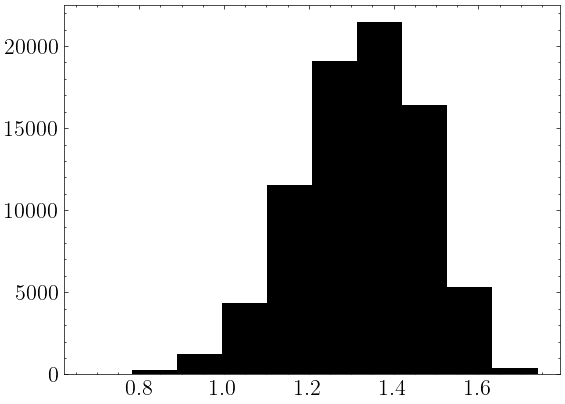

In [217]:
plt.hist(z_109_c1H_TDP_logt_rec)

In [218]:
get_quantiles(z_109_c1H_TDP_logt_rec)

1.33 -0.16 0.14


(array([3.4200e+02, 2.8600e+03, 1.0194e+04, 2.3137e+04, 3.3686e+04,
        9.3720e+03, 1.6900e+02, 1.7700e+02, 1.1000e+01, 5.2000e+01]),
 array([0.14323524, 0.30898562, 0.474736  , 0.64048638, 0.80623676,
        0.97198714, 1.13773753, 1.30348791, 1.46923829, 1.63498867,
        1.80073905]),
 <BarContainer object of 10 artists>)

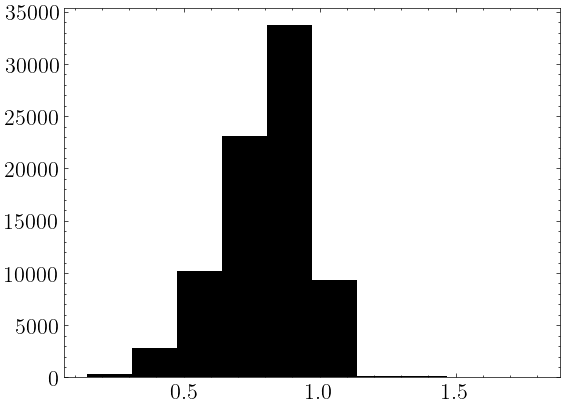

In [219]:
plt.hist(z_109_c1H_TDP_logt_cool-z_109_c1H_TDP_logt_rec)

In [220]:
get_quantiles(z_109_c1H_TDP_logt_cool-z_109_c1H_PIE_logt_rec)

1.28 -0.22 0.21


### c1L

In [221]:
z_109_c1L_TDP_logt_rec, z_109_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_TDP_samples['log_metals_p2'], 
                                                                   z_109_c1_TDP_samples['log_hdens_p2'],
                                                                   z_109_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  132.,   717.,  2630.,  7701., 13688., 22084., 24514.,  7490.,
          936.,   108.]),
 array([1.55526992, 1.62813368, 1.70099745, 1.77386122, 1.84672499,
        1.91958876, 1.99245252, 2.06531629, 2.13818006, 2.21104383,
        2.2839076 ]),
 <BarContainer object of 10 artists>)

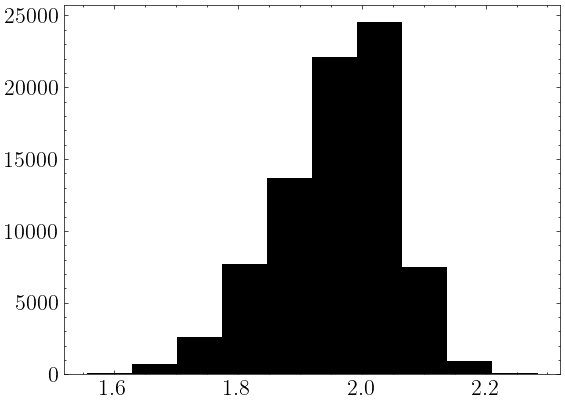

In [222]:
plt.hist(z_109_c1L_TDP_logt_rec)

In [223]:
get_quantiles(z_109_c1L_TDP_logt_rec)

1.97 -0.11 0.08


(array([  166.,  1530.,  5242., 10334., 15888., 20624., 13962.,  7823.,
         3724.,   707.]),
 array([-0.7268247 , -0.6028456 , -0.47886651, -0.35488741, -0.23090831,
        -0.10692921,  0.01704989,  0.14102899,  0.26500809,  0.38898719,
         0.51296629]),
 <BarContainer object of 10 artists>)

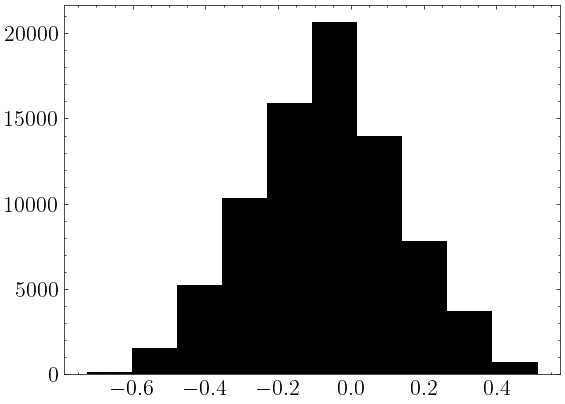

In [224]:
plt.hist(z_109_c1L_TDP_logt_cool-z_109_c1L_TDP_logt_rec)

In [225]:
get_quantiles(z_109_c1L_TDP_logt_cool-z_109_c1L_PIE_logt_rec)

0.32 -0.31 0.28


## c1

In [226]:
z_109_c1_PIE_TDP_samples = pd.read_csv(loaddir+'z=1.09456549/cloudy_fits/PIE+TDP.csv')

### c1H

In [227]:
z_109_c1H_PIE_logT, z_109_c1H_PIE_logt_rec, z_109_c1H_PIE_logt_cool = get_cooling_dist(z_109_c1_PIE_TDP_samples['log_hdens_p1'],
                                                                                       z_109_c1_PIE_TDP_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([  765.,  2656.,  4560.,  8815., 14018., 18153., 17621., 10353.,
         2776.,   283.]),
 array([3.82426374, 3.88366883, 3.94307392, 4.00247902, 4.06188411,
        4.1212892 , 4.1806943 , 4.24009939, 4.29950448, 4.35890957,
        4.41831467]),
 <BarContainer object of 10 artists>)

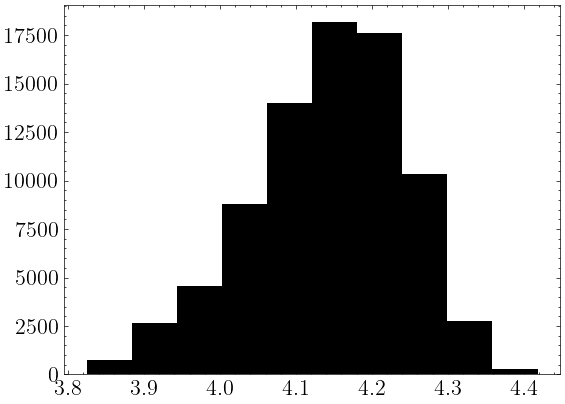

In [228]:
plt.hist(z_109_c1H_PIE_logT)

In [229]:
get_quantiles(z_109_c1H_PIE_logT)

4.15 -0.11 0.09


(array([6.4600e+02, 4.0460e+03, 1.1772e+04, 2.1731e+04, 2.4851e+04,
        1.1961e+04, 3.5950e+03, 1.1320e+03, 2.5300e+02, 1.3000e+01]),
 array([0.54408677, 0.63395802, 0.72382927, 0.81370052, 0.90357177,
        0.99344301, 1.08331426, 1.17318551, 1.26305676, 1.35292801,
        1.44279926]),
 <BarContainer object of 10 artists>)

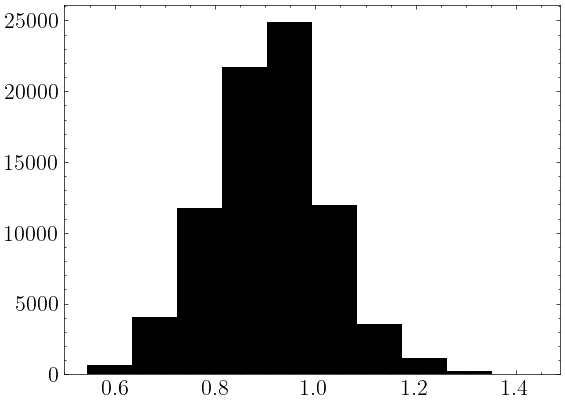

In [230]:
plt.hist(z_109_c1H_PIE_logt_rec)

In [231]:
get_quantiles(z_109_c1H_PIE_logt_rec)

0.91 -0.12 0.11


(array([  395.,  2032.,  3869.,  6475., 12404., 14528., 19397., 14985.,
         5395.,   520.]),
 array([0.23638819, 0.30011744, 0.36384669, 0.42757595, 0.4913052 ,
        0.55503445, 0.6187637 , 0.68249296, 0.74622221, 0.80995146,
        0.87368071]),
 <BarContainer object of 10 artists>)

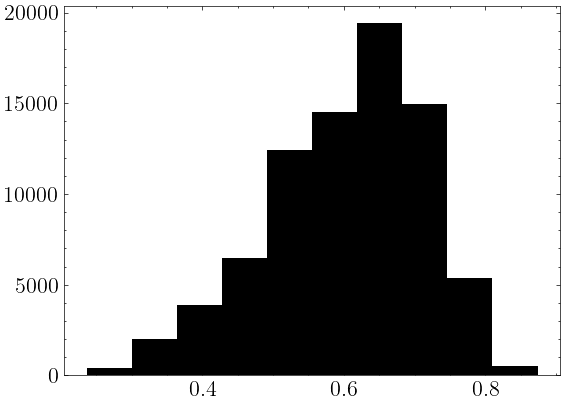

In [232]:
plt.hist(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

In [233]:
get_quantiles(z_109_c1H_PIE_logt_cool-z_109_c1H_PIE_logt_rec)

0.62 -0.13 0.1


### c1L

In [234]:
z_109_c1L_TDP_logt_rec, z_109_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_109_c1_PIE_TDP_samples['log_metals_p2'], 
                                                                   z_109_c1_PIE_TDP_samples['log_hdens_p2'],
                                                                   z_109_c1_PIE_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   44.,   548.,  3130.,  8966., 15738., 29753., 18095.,  3216.,
          471.,    39.]),
 array([1.44247396, 1.55629185, 1.67010974, 1.78392763, 1.89774552,
        2.01156341, 2.1253813 , 2.23919919, 2.35301708, 2.46683497,
        2.58065286]),
 <BarContainer object of 10 artists>)

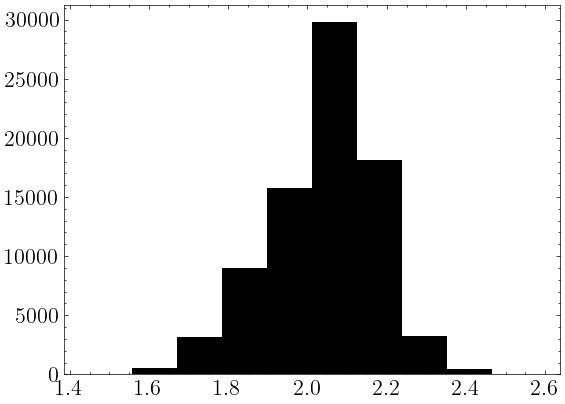

In [235]:
plt.hist(z_109_c1L_TDP_logt_rec)

In [236]:
get_quantiles(z_109_c1L_TDP_logt_rec)

2.06 -0.17 0.1


(array([  254.,  2106.,  7370., 13625., 17160., 19184., 13813.,  5299.,
         1083.,   106.]),
 array([-0.74529093, -0.599043  , -0.45279506, -0.30654713, -0.16029919,
        -0.01405126,  0.13219668,  0.27844461,  0.42469255,  0.57094048,
         0.71718842]),
 <BarContainer object of 10 artists>)

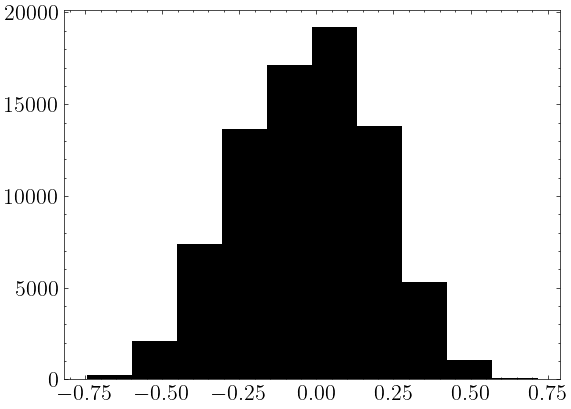

In [237]:
plt.hist(z_109_c1L_TDP_logt_cool-z_109_c1L_TDP_logt_rec)

In [238]:
get_quantiles(z_109_c1L_TDP_logt_cool-z_109_c1L_PIE_logt_rec)

0.46 -0.4 0.31


# z=1.26

## c1

In [239]:
z_126_c1_TDP_samples = pd.read_csv(loaddir+'z=1.25937492/cloudy_fits/TDP.csv')

In [240]:
z_126_c1_TDP_logt_rec, z_126_c1_TDP_logt_cool = get_cooling_dist_TDP(z_126_c1_TDP_samples['log_metals'], 
                                                                   z_126_c1_TDP_samples['log_hdens'],
                                                                   z_126_c1_TDP_samples['logT'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7200e+03, 9.6940e+03, 1.7464e+04, 2.1047e+04, 1.6051e+04,
        9.4230e+03, 3.6780e+03, 7.8400e+02, 1.3300e+02, 6.0000e+00]),
 array([0.8296024 , 0.93958587, 1.04956934, 1.15955281, 1.26953628,
        1.37951975, 1.48950322, 1.59948669, 1.70947016, 1.81945363,
        1.9294371 ]),
 <BarContainer object of 10 artists>)

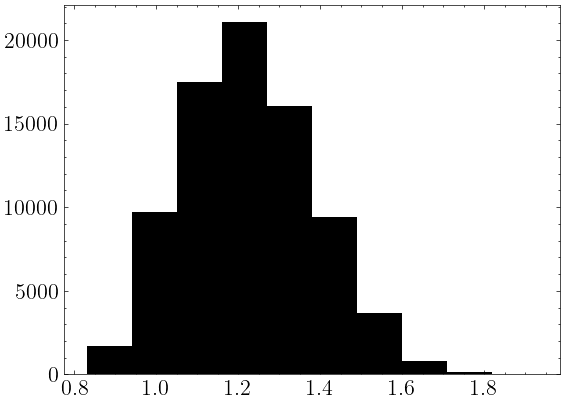

In [241]:
plt.hist(z_126_c1_TDP_logt_rec)

In [242]:
get_quantiles(z_126_c1_TDP_logt_rec)

1.22 -0.16 0.17


(array([6.7610e+03, 3.9808e+04, 2.7797e+04, 5.3240e+03, 3.0900e+02,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-0.3809506 , -0.14841467,  0.08412126,  0.31665719,  0.54919312,
         0.78172905,  1.01426499,  1.24680092,  1.47933685,  1.71187278,
         1.94440871]),
 <BarContainer object of 10 artists>)

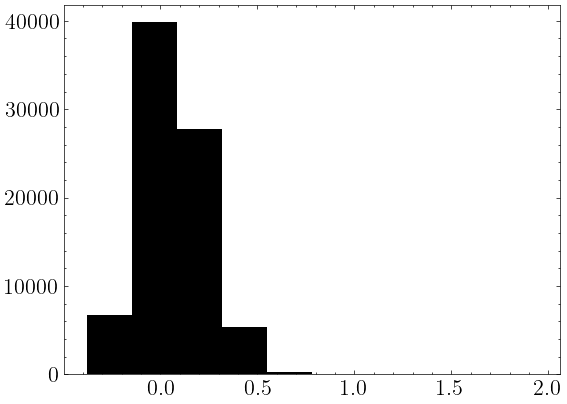

In [243]:
plt.hist(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

In [244]:
get_quantiles(z_126_c1_TDP_logt_cool-z_126_c1_TDP_logt_rec)

0.05 -0.15 0.18


# z=1.27

## c1

In [245]:
z_127_c1_TDP_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/TDP.csv')

### c1H

In [246]:
z_127_c1H_TDP_logt_rec, z_127_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p1'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p1'],
                                                                   z_127_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([  193.,   846.,  1233.,  1377.,  2289.,  6157., 24790., 32318.,
        10322.,   475.]),
 array([-5.62346104e-01, -2.80217881e-01,  1.91034177e-03,  2.84038564e-01,
         5.66166787e-01,  8.48295010e-01,  1.13042323e+00,  1.41255146e+00,
         1.69467968e+00,  1.97680790e+00,  2.25893612e+00]),
 <BarContainer object of 10 artists>)

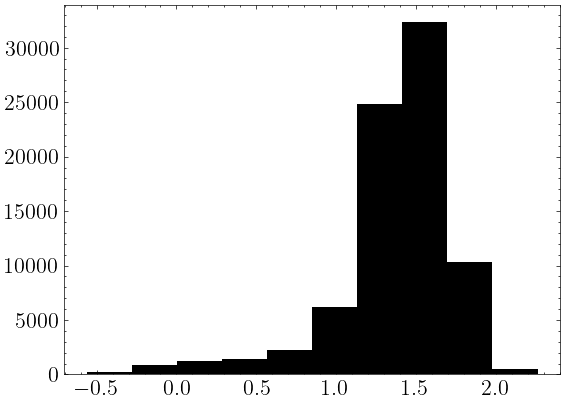

In [247]:
plt.hist(z_127_c1H_TDP_logt_rec)

In [248]:
get_quantiles(z_127_c1H_TDP_logt_rec)

1.44 -0.29 0.24


(array([3.7500e+02, 1.5151e+04, 4.2242e+04, 2.0287e+04, 1.5360e+03,
        1.3000e+02, 1.2400e+02, 1.3300e+02, 1.8000e+01, 4.0000e+00]),
 array([-0.23677611,  0.04836912,  0.33351434,  0.61865957,  0.90380479,
         1.18895002,  1.47409524,  1.75924047,  2.04438569,  2.32953092,
         2.61467615]),
 <BarContainer object of 10 artists>)

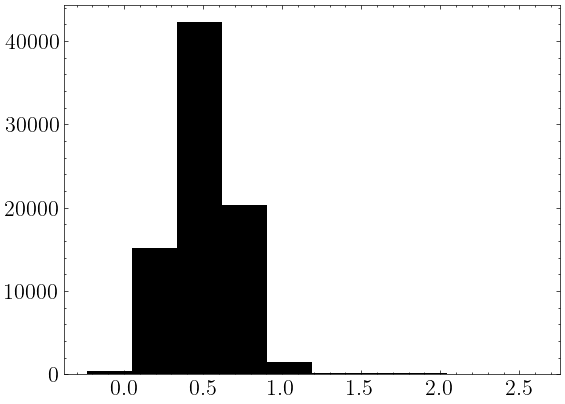

In [249]:
plt.hist(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

In [250]:
get_quantiles(z_127_c1H_TDP_logt_cool-z_127_c1H_TDP_logt_rec)

0.46 -0.15 0.26


### c1L

In [251]:
z_127_c1L_TDP_logt_rec, z_127_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_TDP_samples['log_metals_p2'], 
                                                                   z_127_c1_TDP_samples['log_hdens_p2'],
                                                                   z_127_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   89.,   134.,   244.,   695.,  3831., 14916., 34935., 21000.,
         3892.,   264.]),
 array([1.88817845, 1.99154961, 2.09492078, 2.19829195, 2.30166311,
        2.40503428, 2.50840544, 2.61177661, 2.71514777, 2.81851894,
        2.9218901 ]),
 <BarContainer object of 10 artists>)

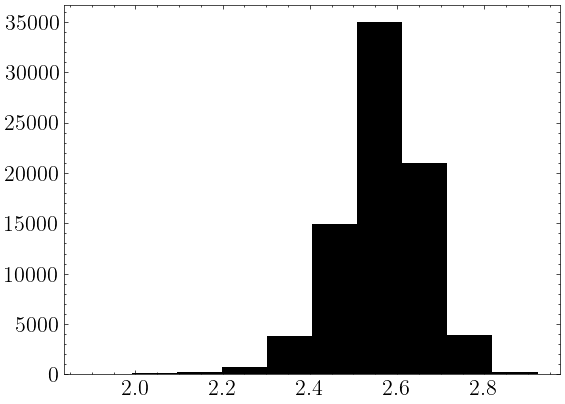

In [252]:
plt.hist(z_127_c1L_TDP_logt_rec)

In [253]:
get_quantiles(z_127_c1L_TDP_logt_rec)

2.57 -0.09 0.09


(array([ 2106., 13541., 23917., 21335., 11805.,  4760.,  1723.,   479.,
          208.,   126.]),
 array([-0.67225878, -0.54647461, -0.42069044, -0.29490627, -0.1691221 ,
        -0.04333793,  0.08244624,  0.20823042,  0.33401459,  0.45979876,
         0.58558293]),
 <BarContainer object of 10 artists>)

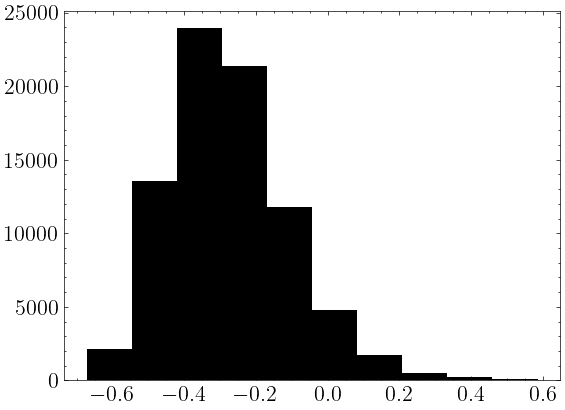

In [254]:
plt.hist(z_127_c1L_TDP_logt_cool-z_127_c1L_TDP_logt_rec)

In [255]:
get_quantiles(z_127_c1L_TDP_logt_cool-z_127_c1L_PIE_logt_rec)

0.08 -0.22 0.26


## c1

In [256]:
z_127_c1_PIE_TDP_samples = pd.read_csv(loaddir+'z=1.27767328/cloudy_fits/PIE+TDP.csv')

### c1H

In [257]:
z_127_c1H_PIE_logT, z_127_c1H_PIE_logt_rec, z_127_c1H_PIE_logt_cool = get_cooling_dist(z_127_c1_PIE_TDP_samples['log_hdens_p1'],
                                                                                       z_127_c1_PIE_TDP_samples['log_metals_p1'],
                                                                                       logq_rec_interp, logt_cool_interp)

(array([  949.,  5671.,  6068.,  8380., 13274., 25002., 14960.,  4034.,
         1458.,   204.]),
 array([3.69296248, 3.7808534 , 3.86874431, 3.95663522, 4.04452613,
        4.13241705, 4.22030796, 4.30819887, 4.39608978, 4.4839807 ,
        4.57187161]),
 <BarContainer object of 10 artists>)

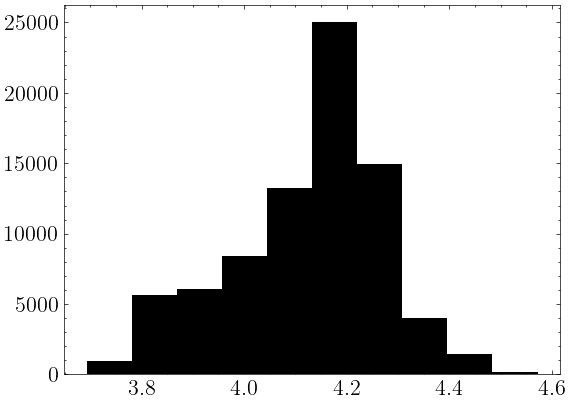

In [258]:
plt.hist(z_127_c1H_PIE_logT)

In [259]:
get_quantiles(z_127_c1H_PIE_logT)

4.16 -0.2 0.1


(array([  999.,  2235.,  4744.,  8638., 12277., 15852., 17465., 13830.,
         3559.,   401.]),
 array([-0.73971132, -0.46084361, -0.18197591,  0.0968918 ,  0.3757595 ,
         0.65462721,  0.93349491,  1.21236262,  1.49123033,  1.77009803,
         2.04896574]),
 <BarContainer object of 10 artists>)

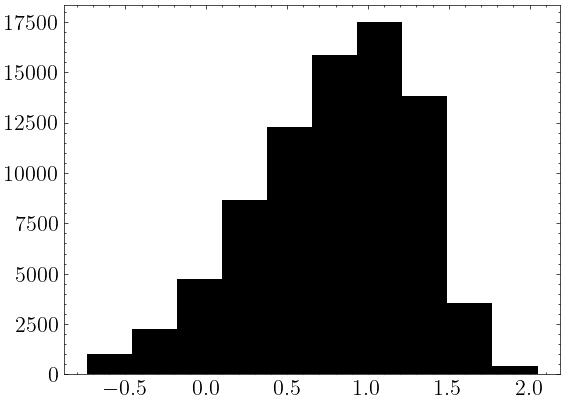

In [260]:
plt.hist(z_127_c1H_PIE_logt_rec)

In [261]:
get_quantiles(z_127_c1H_PIE_logt_rec)

0.86 -0.6 0.44


(array([  151.,   176.,   399.,   409.,  1311.,  3953., 20601., 37852.,
        13140.,  2008.]),
 array([-0.43270951, -0.28983693, -0.14696435, -0.00409177,  0.13878081,
         0.28165339,  0.42452597,  0.56739855,  0.71027113,  0.85314371,
         0.9960163 ]),
 <BarContainer object of 10 artists>)

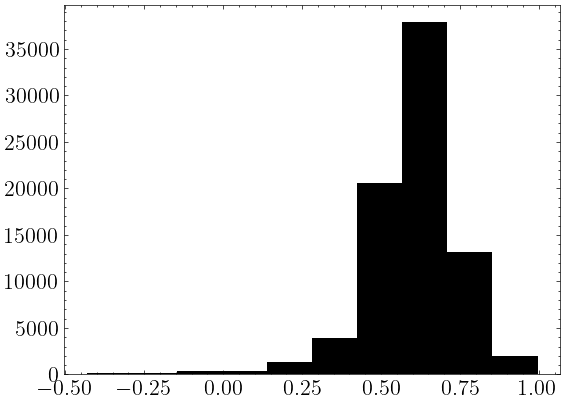

In [262]:
plt.hist(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

In [263]:
get_quantiles(z_127_c1H_PIE_logt_cool-z_127_c1H_PIE_logt_rec)

0.62 -0.12 0.11


### c1L

In [264]:
z_127_c1L_TDP_logt_rec, z_127_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_127_c1_PIE_TDP_samples['log_metals_p2'], 
                                                                   z_127_c1_PIE_TDP_samples['log_hdens_p2'],
                                                                   z_127_c1_PIE_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([   91.,  2779.,  2993., 12185., 43088., 15892.,  1792.,   748.,
          141.,   291.]),
 array([1.96340323, 2.08740716, 2.21141108, 2.33541501, 2.45941894,
        2.58342286, 2.70742679, 2.83143071, 2.95543464, 3.07943857,
        3.20344249]),
 <BarContainer object of 10 artists>)

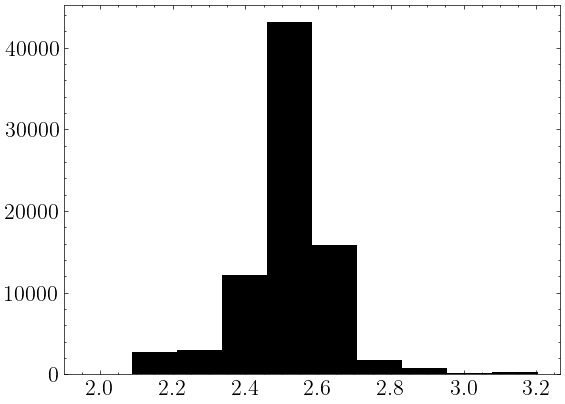

In [265]:
plt.hist(z_127_c1L_TDP_logt_rec)

In [266]:
get_quantiles(z_127_c1L_TDP_logt_rec)

2.53 -0.1 0.08


(array([ 5379., 20682., 18445., 14550., 10260.,  7122.,  2266.,   794.,
          418.,    84.]),
 array([-0.6700832 , -0.54083756, -0.41159191, -0.28234627, -0.15310063,
        -0.02385498,  0.10539066,  0.2346363 ,  0.36388195,  0.49312759,
         0.62237323]),
 <BarContainer object of 10 artists>)

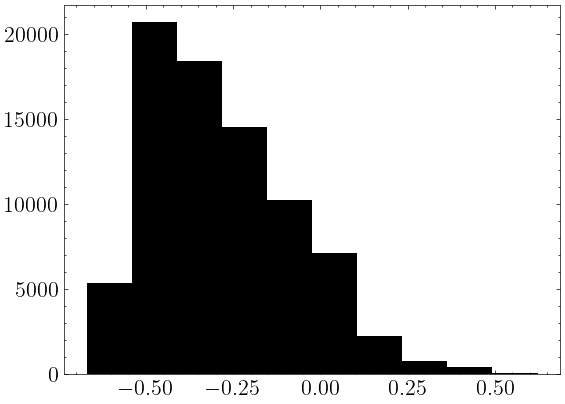

In [267]:
plt.hist(z_127_c1L_TDP_logt_cool-z_127_c1L_TDP_logt_rec)

In [268]:
get_quantiles(z_127_c1L_TDP_logt_cool-z_127_c1L_PIE_logt_rec)

0.01 -0.25 0.3


# DRAFT

# z=0.67

## c1

In [224]:
#z_067_c1_TDP_samples = pd.read_csv(loaddir+'z=0.67545705/cloudy_fits/TDP.csv')

### c1L

In [222]:
z_067_c1L_TDP_logt_rec, z_067_c1L_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p1'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p1'],
                                                                   z_067_c1_TDP_samples['logT_p1'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

NameError: name 'z_067_c1_TDP_samples' is not defined

(array([  233.,   596.,  2033.,  4992.,  8626., 11950., 19349., 23706.,
         8064.,   451.]),
 array([-0.40073044, -0.18844339,  0.02384366,  0.23613071,  0.44841776,
         0.66070481,  0.87299186,  1.08527891,  1.29756596,  1.509853  ,
         1.72214005]),
 <BarContainer object of 10 artists>)

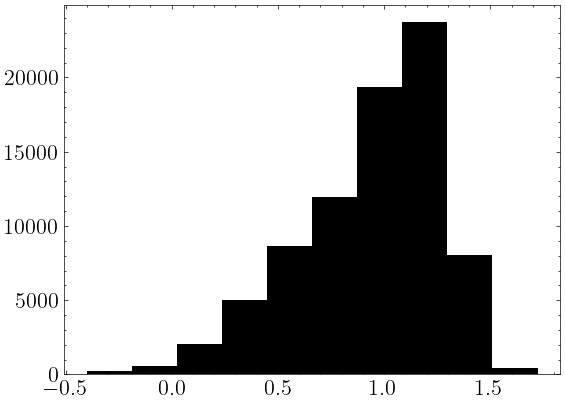

In [159]:
plt.hist(z_067_c1L_TDP_logt_rec)

In [160]:
get_quantiles(z_067_c1L_TDP_logt_rec)

1.01 -0.44 0.23


(array([9.6640e+03, 5.1838e+04, 1.7951e+04, 3.6900e+02, 7.8000e+01,
        3.3000e+01, 2.8000e+01, 3.8000e+01, 0.0000e+00, 1.0000e+00]),
 array([0.25529485, 0.52553135, 0.79576786, 1.06600436, 1.33624087,
        1.60647738, 1.87671388, 2.14695039, 2.41718689, 2.6874234 ,
        2.95765991]),
 <BarContainer object of 10 artists>)

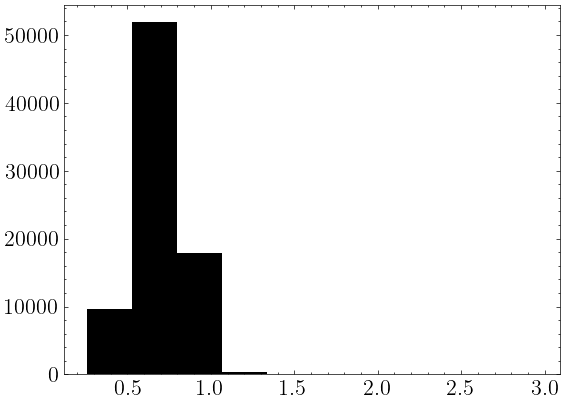

In [161]:
plt.hist(z_067_c1L_TDP_logt_cool-z_067_c1L_TDP_logt_rec)

In [162]:
get_quantiles(z_067_c1L_TDP_logt_cool-z_067_c1L_PIE_logt_rec)

0.9 -0.57 0.46


### c1H

In [163]:
z_067_c1H_TDP_logt_rec, z_067_c1H_TDP_logt_cool = get_cooling_dist_TDP(z_067_c1_TDP_samples['log_metals_p2'], 
                                                                   z_067_c1_TDP_samples['log_hdens_p2'],
                                                                   z_067_c1_TDP_samples['logT_p2'],
                                                                   logq_rec_interp, log_cool_TDP_interp)

(array([1.7100e+02, 7.7000e+02, 1.5050e+03, 3.8960e+03, 9.6570e+03,
        1.7084e+04, 2.8406e+04, 1.7417e+04, 1.0810e+03, 1.3000e+01]),
 array([1.75976289, 1.86707555, 1.97438821, 2.08170087, 2.18901353,
        2.29632619, 2.40363886, 2.51095152, 2.61826418, 2.72557684,
        2.8328895 ]),
 <BarContainer object of 10 artists>)

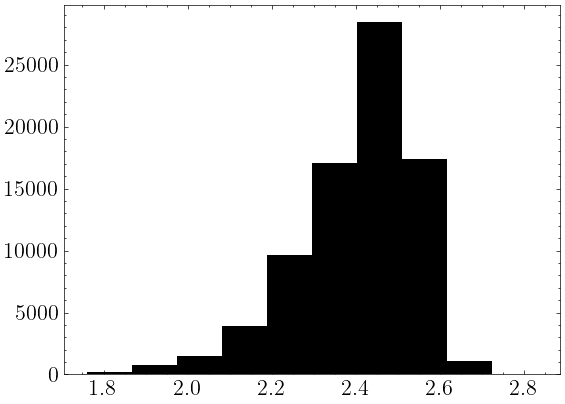

In [164]:
plt.hist(z_067_c1H_TDP_logt_rec)

In [165]:
get_quantiles(z_067_c1H_TDP_logt_rec)

2.43 -0.16 0.1


(array([  479.,  1612.,  2644.,  3592.,  6503., 11710., 23289., 23859.,
         5708.,   604.]),
 array([-0.79916646, -0.66226482, -0.52536319, -0.38846156, -0.25155993,
        -0.1146583 ,  0.02224334,  0.15914497,  0.2960466 ,  0.43294823,
         0.56984987]),
 <BarContainer object of 10 artists>)

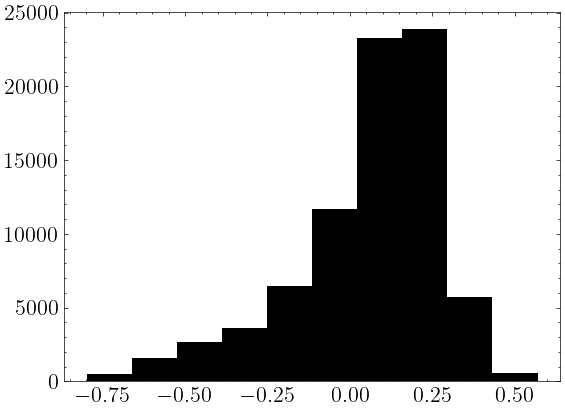

In [166]:
plt.hist(z_067_c1H_TDP_logt_cool-z_067_c1H_TDP_logt_rec)

In [167]:
get_quantiles(z_067_c1H_TDP_logt_cool-z_067_c1H_PIE_logt_rec)

0.57 -0.34 0.2
